In [100]:
## các thư viện sử dụng
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time as t

In [101]:
### Cấu hính cho thư viện 
# 1. Cấu hình Pandas hiển thị tối đa số hàng (106 hoặc nhiều hơn)
pd.set_option('display.max_rows', 150)

# (Tùy chọn) Cấu hình không giới hạn chiều rộng và số cột để không bị gãy dòng
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# BÁO CÁO PHÂN TÍCH CẤU TRÚC DỮ LIỆU (HOME CREDIT DEFAULT RISK)

---

## 1. PHÂN LOẠI CẤU TRÚC BẢNG (TABLE HIERARCHY)

###  Bảng chính (Main Table / Fact Table)
* **`application_train.csv` / `application_test.csv`**:
  * Là bảng trung tâm của toàn bộ bộ dữ liệu.
  * Chứa thông tin hồ sơ vay hiện tại của khách hàng (nhân khẩu học, thu nhập, tài sản, các chỉ số điểm rủi ro bên ngoài).
  * Chứa biến mục tiêu `TARGET` (chỉ có ở tập Train):
    * `0`: Khách hàng hoàn trả khoản vay đúng hạn.
    * `1`: Khách hàng gặp khó khăn tài chính / vỡ nợ.

---

### Bảng phụ (Dimension / Transactional Tables)
Các bảng phụ liên kết với bảng chính thông qua khóa ngoại **`SK_ID_CURR`** (Mã định danh khoản vay hiện tại) và được chia thành 2 nhánh dữ liệu:

#### Nhánh 1: Dữ liệu Tín dụng bên ngoài (Credit Bureau Data)
* **`bureau.csv`**:
  * Lịch sử các khoản vay của khách hàng tại các tổ chức tín dụng khác (ngân hàng khác, công ty tài chính khác).
* **`bureau_balance.csv`**:
  * Lịch sử số dư và tình trạng thanh toán chi tiết theo từng tháng của các khoản vay trong `bureau.csv`.
  * Liên kết với `bureau.csv` thông qua **`SK_ID_BUREAU`**.

#### Nhánh 2: Dữ liệu Tín dụng nội bộ (Home Credit Historical Data)
* **`previous_application.csv`**:
  * Lịch sử tất cả các lần đăng ký vay trước đây của khách hàng ngay tại Home Credit (bao gồm các hồ sơ được duyệt, bị từ chối, hoặc bị hủy).
* **`POS_CASH_balance.csv`**:
  * Lịch sử số dư hàng tháng của các khoản vay trả góp tại điểm bán (POS) hoặc vay tiền mặt trước đây tại Home Credit.
  * Liên kết thông qua **`SK_ID_CURR`** và **`SK_ID_PREV`**.
* **`credit_card_balance.csv`**:
  * Lịch sử giao dịch, hạn mức, dư nợ hàng tháng của các thẻ tín dụng khách hàng sở hữu tại Home Credit.
  * Liên kết thông qua **`SK_ID_CURR`** và **`SK_ID_PREV`**.
* **`installments_payments.csv`**:
  * Chi tiết lịch sử từng đợt thanh toán thực tế (số tiền phải trả vs. số tiền thực trả, ngày trả vs. ngày đến hạn) của các khoản vay trước đây tại Home Credit.
  * Liên kết thông qua **`SK_ID_CURR`** và **`SK_ID_PREV`**.

---

###  Bảng hỗ trợ (Support Files)
* **`HomeCredit_columns_description.csv`**: Data Dictionary chi tiết giải thích ý nghĩa từng cột dữ liệu.
* **`sample_submission.csv`**: File mẫu quy định định dạng đầu ra để nộp kết quả dự đoán.

---

## 2. MỨC DỮ LIỆU (DATA GRAIN) & MỐI QUAN HỆ GIỮA CÁC BẢNG

| Bảng Dữ Liệu | Mức Dữ Liệu (Grain) | Mối Quan Hệ với Bảng Chính | Khóa Liên Kết (Primary / Foreign Key) |
| :--- | :--- | :---: | :--- |
| **`application_{train\|test}`** | **1 dòng = 1 Khoản vay hiện tại** *(1 khách hàng tại thời điểm nộp đơn)* | **Bảng gốc (Main)** | `SK_ID_CURR` |
| **`bureau`** | **1 dòng = 1 Khoản vay trước đây tại TCTD khác** | $1 : N$ | `SK_ID_CURR` |
| **`bureau_balance`** | **1 dòng = 1 Tháng lịch sử của 1 khoản vay tại TCTD khác** | $1 : N : M$ | `SK_ID_BUREAU` |
| **`previous_application`** | **1 dòng = 1 Đơn đăng ký vay trước đây tại Home Credit** | $1 : N$ | `SK_ID_CURR` |
| **`POS_CASH_balance`** | **1 dòng = 1 Tháng lịch sử của 1 khoản vay POS/Cash tại Home Credit** | $1 : N : M$ | `SK_ID_CURR` & `SK_ID_PREV` |
| **`credit_card_balance`** | **1 dòng = 1 Tháng lịch sử của 1 thẻ tín dụng tại Home Credit** | $1 : N : M$ | `SK_ID_CURR` & `SK_ID_PREV` |
| **`installments_payments`** | **1 dòng = 1 Giao dịch thanh toán (hoặc 1 kỳ bỏ lỡ) tại Home Credit** | $1 : N : M$ | `SK_ID_CURR` & `SK_ID_PREV` |

---

## 3. DATA DICTIONARY — MÔ TẢ CÁC THUỘC TÍNH QUAN TRỌNG

###  Bảng chính `application_train.csv`
* **`SK_ID_CURR`**: ID duy nhất của khoản vay hiện tại (Khóa chính).
* **`TARGET`**: Biến mục tiêu ($0$: Khách hàng uy tín, $1$: Khách hàng vỡ nợ).
* **`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`**: Điểm số rủi ro chuẩn hóa từ các nguồn bên ngoài (nhóm đặc trưng có tương quan mạnh nhất với `TARGET`).
* **`DAYS_BIRTH`**: Tuổi khách hàng (tính bằng số ngày âm so với ngày nộp đơn).
* **`DAYS_EMPLOYED`**: Số ngày làm việc tại công ty hiện tại (giá trị ngoại lệ $365243$ đại diện cho người không đi làm/nghỉ hưu).
* **`AMT_CREDIT`**: Số tiền tín dụng của khoản vay hiện tại.
* **`AMT_ANNUITY`**: Số tiền trả góp hàng tháng.
* **`AMT_INCOME_TOTAL`**: Tổng thu nhập của khách hàng.

###  Các bảng phụ (Phục vụ Feature Aggregation)
* **`bureau.csv` $\rightarrow$ `DAYS_CREDIT`**: Số ngày từ lúc mở khoản vay cũ ở TCTD khác đến hiện tại.
* **`previous_application.csv` $\rightarrow$ `NAME_CONTRACT_STATUS`**: Trạng thái hồ sơ cũ tại Home Credit (`Approved`, `Refused`, `Canceled`).
* **`installments_payments.csv` $\rightarrow$ `DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT`**: Độ lệch số ngày trả chậm hoặc trả sớm hơn so với hạn định.
* **`credit_card_balance.csv` $\rightarrow$ `AMT_BALANCE` / `AMT_CREDIT_LIMIT_ACTUAL`**: Tỷ lệ sử dụng hạn mức thẻ tín dụng.

---

### CHIẾN LƯỢC XỬ LÝ DỮ LIỆU (FEATURE ENGINEERING STRATEGY)

1. **Gom nhóm về cùng Grain (Aggregation):**
   * Do các bảng phụ có quan hệ $1 : N$ hoặc $1 : N : M$ với bảng gốc, bắt buộc phải thực hiện `groupby('SK_ID_CURR')` và tính toán các chỉ số tổng hợp (`mean`, `sum`, `max`, `min`, `std`) trước khi merge vào bảng chính.
   * Mục tiêu cuối cùng: Đưa toàn bộ dataset về cùng mức Grain: **1 dòng = 1 `SK_ID_CURR`**.

2. **Dữ liệu chuỗi thời gian (Time-series Windowing):**
   * Ở các bảng lịch sử dư nợ `_balance`, tính toán thêm các đặc trưng theo cửa sổ thời gian gần nhất (ví dụ: 3 tháng, 6 tháng, 12 tháng gần nhất) để phản ánh chính xác xu hướng hành vi tài chính gần đây của khách hàng.!

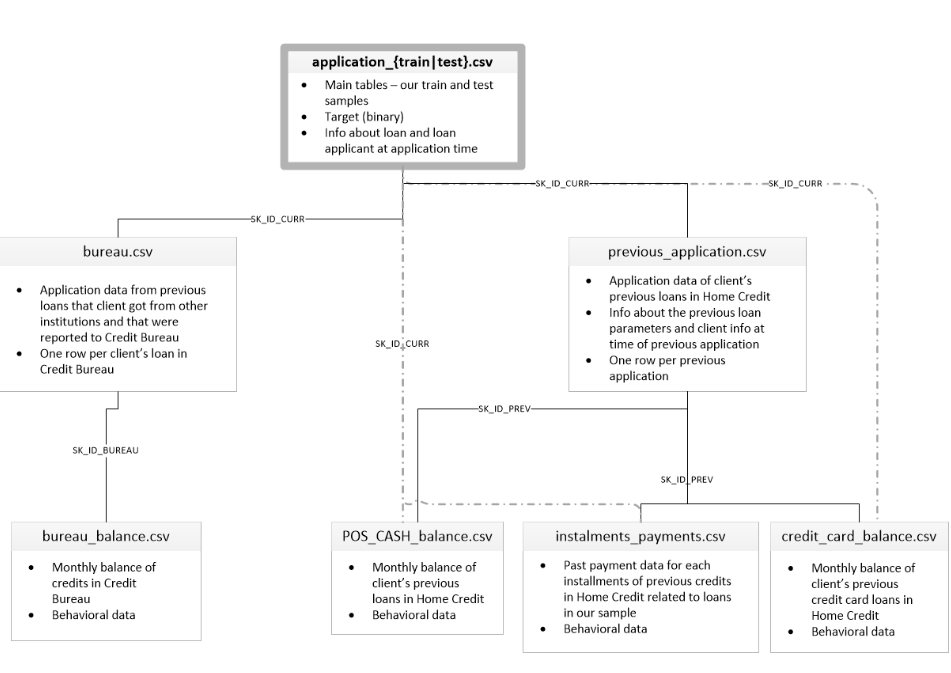

In [120]:
# Đường dẫn của data
application_train_path = r'../../IEEE-CIS-Fraud-Detection/Data/01_Raw_data/home-credit-default-risk/application_train.csv'
application_test_path = r'../../IEEE-CIS-Fraud-Detection/Data/01_Raw_data/home-credit-default-risk/application_test.csv'
bureau_path = r'../../IEEE-CIS-Fraud-Detection/Data/01_Raw_data/home-credit-default-risk/bureau.csv'
credit_card_balance_path = r'../../IEEE-CIS-Fraud-Detection/Data/01_Raw_data/home-credit-default-risk/credit_card_balance.csv'
pos_cash_balance_path = r'../../IEEE-CIS-Fraud-Detection/Data/01_Raw_data/home-credit-default-risk/POS_CASH_balance.csv'
installment_payments_path = r'../../IEEE-CIS-Fraud-Detection/Data/01_Raw_data/home-credit-default-risk/installments_payments.csv'
previous_application_path = r'../../IEEE-CIS-Fraud-Detection/Data/01_Raw_data/home-credit-default-risk/previous_application.csv'
HomeCredit_path = r'../../IEEE-CIS-Fraud-Detection/Data/01_Raw_data/home-credit-default-risk/HomeCredit_columns_description.csv'


## Đọc Data từ transaction_data_path và identity_data_path

In [121]:
# Đọc data từ transaction_data_path
application_train = pd.read_csv(application_train_path)
bureau = pd.read_csv(bureau_path)
credit_card_balance = pd.read_csv(credit_card_balance_path)
pos_cash_balance = pd.read_csv(pos_cash_balance_path)
installment_payments = pd.read_csv(installment_payments_path)
previous_application = pd.read_csv(previous_application_path)
HomeCredit_path = pd.read_csv(HomeCredit_path,encoding='latin-1') # do file này có chứa các ký tự đặc biệt nên cần thêm encoding='latin-1' để đọc dữ liệu

## Hàm phân tích tổng quan cho từng tập data

In [122]:
def analyze_columns_overview(df, overview_df=True):
    """
    Hàm phân tích tổng quan từng cột trong DataFrame:
    - Tên cột (Column Name)
    - Kiểu dữ liệu (Data Type - info())
    - Số lượng giá trị khác nhau (nunique())
    - Tỷ lệ giá trị khác nhau (Unique Ratio %)
    - Số lượng & Tỷ lệ giá trị khuyết thiếu (Missing Values & Ratio %)
    - Nếu overview_df=True: trả về DataFrame tổng quan
    - Nếu overview_df=False: in chi tiết từng cột bằng vòng lặp
    """
    total_rows = len(df)
    
    summary_data = []
    for col in df.columns:
        dtype = str(df[col].dtype)
        n_unique = df[col].nunique(dropna=True)
        unique_ratio = (n_unique / total_rows) * 100
        n_missing = df[col].isnull().sum()
        missing_ratio = (n_missing / total_rows) * 100
        
        summary_data.append({
            'Column Name': col,
            'Data Type': dtype,
            'Unique Count': n_unique,
            'Unique Ratio (%)': round(unique_ratio, 4),
            'Missing Count': n_missing,
            'Missing Ratio (%)': round(missing_ratio, 2)
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Nếu người dùng muốn xem dưới dạng DataFrame
    if overview_df:
        # In thống kê tổng quan theo kiểu dữ liệu
        print("=" * 60)
        print("THỐNG KÊ SỐ LƯỢNG CỘT THEO KIỂU DỮ LIỆU (DTYPE SUMMARY)")
        print("=" * 60)
        dtype_counts = summary_df['Data Type'].value_counts()
        print(dtype_counts.to_string())
        print("-" * 60)
        print(f"TỔNG SỐ CỘT (TOTAL COLUMNS): {len(df.columns)}")
        print(f"TỔNG SỐ DÒNG (TOTAL ROWS): {total_rows}")
        print("=" * 60 + "\n")
        
        # Đặt tên cột làm index
        return summary_df
    
    else:
        # Nếu overview_df=False thì in chi tiết từng cột
        for col in df.columns:
            print('=='*100)
            analyze_single_column(df, col)
            print('=='*100)


def analyze_single_column(df, column_name):
    """
    Hàm phân tích chi tiết cho duy nhất 1 cột trong DataFrame
    """
    total_rows = len(df)
    col = df[column_name]
    
    n_unique = col.nunique()
    unique_ratio = (n_unique / total_rows) * 100
    n_missing = col.isnull().sum()
    missing_ratio = (n_missing / total_rows) * 100
    
    print(f" PHÂN TÍCH CHI TIẾT CỘT: [{column_name}]")
    print(f"- Kiểu dữ liệu (DataType):     {col.dtype}")
    print(f"- Số lượng giá trị duy nhất:   {n_unique:,}")
    print(f"- Tỷ lệ giá trị duy nhất:      {unique_ratio:.4f}%")
    print(f"- Số giá trị bị KHUYẾT (Null): {n_missing:,} ({missing_ratio:.2f}%)")
    
    # Hiển thị Top 5 giá trị xuất hiện nhiều nhất
    print("\n Top 5 giá trị phổ biến nhất:")
    print(col.value_counts(dropna=False).head(5))

In [123]:
def describe_separated_data(df):
    """
    Hàm phân tích mô tả (describe) phân chia rõ ràng giữa Dạng Số và Dạng Chữ.
    
    - Dạng Số (Numerical): Count, Mean, Std, Min, 25%, 50% (Median), 75%, Max.
    - Dạng Chữ (Categorical): Count, Unique, Top (phổ biến nhất), Freq (tần suất).
    """
    print("=" * 70)
    print("1. THỐNG KÊ MÔ TẢ CHO DỮ LIỆU DẠNG SỐ (NUMERICAL FEATURES)")
    print("=" * 70)
    
    # Lọc các cột dạng số (int, float)
    num_df = df.select_dtypes(include=['number'])
    
    if not num_df.empty:
        # describe() mặc định cho biến số đã có: count, mean, std, min, 25%, 50%, 75%, max
        num_stats = num_df.describe().T
        
        # Thêm/Đổi tên rõ ràng cột Median (chính là phân vị 50%)
        num_stats['median'] = num_stats['50%']
        
        # Sắp xếp lại thứ tự các cột hiển thị cho trực quan
        ordered_cols = ['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']
        num_stats = num_stats[ordered_cols]
        
        display(num_stats)
    else:
        print("Không có cột dữ liệu dạng số trong DataFrame.")
        
    print("\n" + "=" * 70)
    print("2. THỐNG KÊ MÔ TẢ CHO DỮ LIỆU DẠNG CHỮ / PHÂN LOẠI (CATEGORICAL FEATURES)")
    print("=" * 70)
    
    # Lọc các cột dạng chữ/chuỗi (object, category)
    cat_df = df.select_dtypes(include=['object', 'category'])
    
    if not cat_df.empty:
        # describe(include=['object', 'category']) cho dạng chữ
        cat_stats = cat_df.describe().T
        display(cat_stats)
    else:
        print("Không có cột dữ liệu dạng chữ/phân loại trong DataFrame.")


In [124]:
def check_and_plot_missing(df, threshold=50.0):
    # 1. Tính số lượng và phần trăm giá trị thiếu theo từng cột
    missing_values = df.isnull().sum()
    missing_percent = 100 * missing_values / len(df)
    
    # Tạo DataFrame tổng hợp
    missing_data = pd.DataFrame({
        'MissingCount': missing_values,
        'MissingPercent': missing_percent,
        'DataType': df.dtypes.astype(str)
    })
    
    # Lọc ra các cột có dữ liệu thiếu (> 0%)
    missing_df = missing_data[missing_data['MissingPercent'] > 0]
    
    # 2. Phân chia Numeric và Categorical
    numeric_df = missing_df[missing_df['DataType'].str.contains('int|float')].sort_values(by='MissingPercent', ascending=False)
    category_df = missing_df[~missing_df['DataType'].str.contains('int|float')].sort_values(by='MissingPercent', ascending=False)
    
    sns.set_theme(style="whitegrid")
    
    # --- BIỂU ĐỒ 1: NUMERIC FEATURES ---
    plt.figure(figsize=(20, 10))
    if not numeric_df.empty:
        sns.barplot(x=numeric_df.index, y=numeric_df['MissingPercent'], palette="viridis")
        plt.xticks(rotation=90)
        plt.ylabel('% giá trị bị thiếu')
        plt.xlabel('Tên cột (Numeric)')
        plt.title('Tỷ lệ % giá trị bị thiếu - Các cột Numeric')
        plt.xlim(-0.5, len(numeric_df) - 0.5)
        plt.ylim(0, 100)
        plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Ngưỡng {threshold}%')
        plt.legend()
    else:
        plt.text(0.5, 0.5, 'Không có cột Numeric nào bị thiếu dữ liệu', ha='center', va='center', fontsize=18)
        plt.title('Tỷ lệ % giá trị bị thiếu - Các cột Numeric')
        
    plt.tight_layout()
    plt.show()
    
    # --- BIỂU ĐỒ 2: CATEGORICAL FEATURES ---
    plt.figure(figsize=(20, 10))
    if not category_df.empty:
        sns.barplot(x=category_df.index, y=category_df['MissingPercent'], palette="magma")
        plt.xticks(rotation=90)
        plt.ylabel('% giá trị bị thiếu')
        plt.xlabel('Tên cột (Categorical)')
        plt.title('Tỷ lệ % giá trị bị thiếu - Các cột Categorical')
        plt.xlim(-0.5, len(category_df) - 0.5)
        plt.ylim(0, 100)
        plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Ngưỡng {threshold}%')
        plt.legend()
    else:
        plt.text(0.5, 0.5, 'Không có cột Categorical nào bị thiếu dữ liệu', ha='center', va='center', fontsize=18)
        plt.title('Tỷ lệ % giá trị bị thiếu - Các cột Categorical')
        
    plt.tight_layout()
    plt.show()
    
    # 3. In thông báo các cột vượt ngưỡng 50%
    high_missing = missing_df[missing_df['MissingPercent'] >= threshold].sort_values(by='MissingPercent', ascending=False)
    print(f"Các cột có tỷ lệ % giá trị bị thiếu >= {threshold}%:")
    if not high_missing.empty:
        for col, row in high_missing.iterrows():
            print(f"- {col} ({row['DataType']}): {row['MissingPercent']:.2f}%")
    else:
        print("Không có cột nào vượt ngưỡng.")

    return numeric_df, category_df

In [125]:
def check_duplicates(df, subset=None, keep='first', drop=False):
    """
    Kiem tra va xu ly du lieu trung lap trong DataFrame.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame can kiem tra.
    subset : list or str, optional (default=None)
        Danh sach cac cot can kiem tra trung lap. 
        Neu None: Kiem tra trung lap tren TOAN BO cac cot.
    keep : {'first', 'last', False}, default 'first'
        - 'first': Đánh dấu dòng trùng ngoại trừ dòng đầu tiên.
        - 'last': Đánh dấu dòng trùng ngoại trừ dòng cuối cùng.
        - False: Đánh dấu TẤT CẢ các dòng trùng lặp.
    drop : bool, default False
        Neu True: Tra ve DataFrame da xoa cac dong trung lap.
        Neu False: Tra ve DataFrame chi chua cac dong bi trung lap de kiem tra.
        
    Returns:
    --------
    tuple: (total_duplicates, dup_df_or_cleaned_df)
    """
    # 1. Đếm tổng số dòng bị trùng lặp
    dup_mask = df.duplicated(subset=subset, keep=keep)
    total_duplicates = dup_mask.sum()
    
    print("=" * 50)
    print("BÁO CÁO KIỂM TRA TRÙNG LẶP DỮ LIỆU")
    print("=" * 50)
    print(f"- Tổng số dòng trong DataFrame: {len(df):,}")
    print(f"- Kiểm tra trên nhóm cột: {subset if subset else 'Toàn bộ các cột'}")
    print(f"- Số dòng bị trùng lặp: {total_duplicates:,} ({total_duplicates/len(df)*100:.2f}%)")
    print("=" * 50)
    
    # 2. Xử lý trả về kết quả
    if drop:
        # Xóa các dòng trùng và trả về df sạch
        df_cleaned = df.drop_duplicates(subset=subset, keep=keep).reset_index(drop=True)
        print(f"-> Đã xóa {total_duplicates:,} dòng trùng. Số dòng còn lại: {len(df_cleaned):,}")
        return total_duplicates, df_cleaned
    else:
        # Trả về DataFrame chỉ chứa các dòng bị trùng để người dùng xem chi tiết
        dup_rows = df[dup_mask].sort_values(by=subset if subset else list(df.columns))
        return total_duplicates, dup_rows

In [126]:
def check_logical_errors(df):
    """
    Kiem tra cac gia tri sai logic nghiep vu trong DataFrame application_train.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame can kiem tra.
        
    Returns:
    --------
    pd.DataFrame: Bang tong hop cac loi logic va so luong dong vi pham.
    """
    errors = []
    
    def log_error(rule_name, mask, description):
        count = mask.sum()
        pct = (count / len(df)) * 100
        errors.append({
            'Lỗi logic / Quy tắc': rule_name,
            'Số dòng vi phạm': count,
            'Tỷ lệ (%)': round(pct, 4),
            'Mô tả': description
        })

    # 1. Kiểm tra DAYS_EMPLOYED bất thường (Mã hóa 365243 đại diện nghỉ hưu/thất nghiệp)
    if 'DAYS_EMPLOYED' in df.columns:
        mask = df['DAYS_EMPLOYED'] == 365243
        log_error('DAYS_EMPLOYED == 365243', mask, 'Giá trị dị biệt đại diện cho Thất nghiệp/Nghỉ hưu (~1000 năm)')
        
        # Kiểm tra nếu DAYS_EMPLOYED > 0 mà không phải 365243
        mask_pos = (df['DAYS_EMPLOYED'] > 0) & (df['DAYS_EMPLOYED'] != 365243)
        log_error('DAYS_EMPLOYED > 0 (Dương bất thường)', mask_pos, 'Số ngày làm việc dương (ngoại trừ 365243)')

    # 2. Kiểm tra DAYS_BIRTH > 0 (Tuổi âm)
    if 'DAYS_BIRTH' in df.columns:
        mask = df['DAYS_BIRTH'] > 0
        log_error('DAYS_BIRTH > 0', mask, 'Ngày sinh là giá trị dương (chưa sinh ra)')

    # 3. Số con lớn hơn số thành viên gia đình
    if 'CNT_CHILDREN' in df.columns and 'CNT_FAM_MEMBERS' in df.columns:
        mask = df['CNT_CHILDREN'] > df['CNT_FAM_MEMBERS']
        log_error('CNT_CHILDREN > CNT_FAM_MEMBERS', mask, 'Số con nhiều hơn tổng số thành viên gia đình')

    # 4. Khoản trả góp hàng năm lớn hơn tổng khoản vay
    if 'AMT_ANNUITY' in df.columns and 'AMT_CREDIT' in df.columns:
        mask = df['AMT_ANNUITY'] > df['AMT_CREDIT']
        log_error('AMT_ANNUITY > AMT_CREDIT', mask, 'Tiền trả góp hàng năm lớn hơn tổng số tiền vay')

    # 5. Tuổi xe hơi âm hoặc quá cao (> 80 năm)
    if 'OWN_CAR_AGE' in df.columns:
        mask = (df['OWN_CAR_AGE'] < 0) | (df['OWN_CAR_AGE'] > 80)
        log_error('OWN_CAR_AGE bất thường', mask, 'Tuổi xe bị âm hoặc lớn hơn 80 năm')

    # 6. Kiểm tra các cột cờ Binary (Phải là 0, 1 hoặc NaN)
    flag_cols = [c for c in df.columns if c.startswith('FLAG_') or c == 'TARGET']
    for col in flag_cols:
        if col in df.columns:
            mask = ~df[col].isin([0, 1, np.nan])
            if mask.sum() > 0:
                log_error(f'Cột {col} không hợp lệ', mask, 'Giá trị nằm ngoài khoảng [0, 1]')

    # 7. Giờ bắt đầu nộp hồ sơ ngoài khoảng [0, 23]
    if 'HOUR_APPR_PROCESS_START' in df.columns:
        mask = (df['HOUR_APPR_PROCESS_START'] < 0) | (df['HOUR_APPR_PROCESS_START'] > 23)
        log_error('HOUR_APPR_PROCESS_START ngoài [0-23]', mask, 'Khung giờ không hợp lệ')

    # Tổng hợp kết quả thành DataFrame
    report_df = pd.DataFrame(errors)
    
    print("=" * 70)
    print("BÁO CÁO KIỂM TRA LỖI LOGIC DỮ LIỆU")
    print("=" * 70)
    
    return report_df

In [127]:
def check_logical_errors_v2(df):
    """
    Kiem tra cac gia tri sai logic nghiep vu va quet cac cot Nhi phan (nunique == 2)
    nam ngoai [0, 1].
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame application_train can kiem tra.
        
    Returns:
    --------
    pd.DataFrame: Bang tong hop cac loi logic va so luong dong vi pham.
    """
    errors = []
    
    def log_error(rule_name, mask, description):
        count = mask.sum()
        pct = (count / len(df)) * 100
        errors.append({
            'Lỗi logic / Quy tắc': rule_name,
            'Số dòng vi phạm': count,
            'Tỷ lệ (%)': round(pct, 4),
            'Mô tả': description
        })

    # =========================================================================
    # 1. VÒNG LẶP QUÉT TẤT CẢ CỘT CÓ NUNIQUE() == 2
    # =========================================================================
    print("--- QUÉT CÁC CỘT NHỊ PHÂN (NUNIQUE == 2) ---")
    binary_cols = [col for col in df.columns if df[col].nunique(dropna=True) == 2]
    
    for col in binary_cols:
        # Lấy các giá trị duy nhất thực tế trong cột (bỏ qua NaN)
        unique_vals = set(df[col].dropna().unique())
        
        # Kiểm tra xem tập giá trị này có phải là con của {0, 1} hoặc {0.0, 1.0} không
        if not unique_vals.issubset({0, 1, 0.0, 1.0}):
            # Tạo mask tìm các dòng chứa giá trị nằm ngoài [0, 1]
            mask = ~df[col].isin([0, 1, 0.0, 1.0]) & df[col].notna()
            log_error(
                f'Cột nhị phân `{col}` sai định dạng [0, 1]', 
                mask, 
                f'Cột có 2 giá trị là {list(unique_vals)}, không thuộc bộ [0, 1]'
            )

    # =========================================================================
    # 2. KIỂM TRA CÁC LỖI LOGIC NGHIỆP VỤ ĐẶC THÙ
    # =========================================================================
    
    # DAYS_EMPLOYED == 365243 (Mã hóa nghỉ hưu / thất nghiệp)
    if 'DAYS_EMPLOYED' in df.columns:
        mask = df['DAYS_EMPLOYED'] == 365243
        log_error('DAYS_EMPLOYED == 365243', mask, 'Giá trị dị biệt đại diện cho Thất nghiệp/Nghỉ hưu (~1000 năm)')
        
        mask_pos = (df['DAYS_EMPLOYED'] > 0) & (df['DAYS_EMPLOYED'] != 365243)
        log_error('DAYS_EMPLOYED > 0 (Dương bất thường)', mask_pos, 'Số ngày làm việc dương (ngoại trừ 365243)')

    # DAYS_BIRTH > 0 (Tuổi âm)
    if 'DAYS_BIRTH' in df.columns:
        mask = df['DAYS_BIRTH'] > 0
        log_error('DAYS_BIRTH > 0', mask, 'Ngày sinh là giá trị dương (chưa sinh ra)')

    # Số con > Số thành viên gia đình
    if 'CNT_CHILDREN' in df.columns and 'CNT_FAM_MEMBERS' in df.columns:
        mask = df['CNT_CHILDREN'] > df['CNT_FAM_MEMBERS']
        log_error('CNT_CHILDREN > CNT_FAM_MEMBERS', mask, 'Số con nhiều hơn tổng số thành viên gia đình')

    # AMT_ANNUITY > AMT_CREDIT
    if 'AMT_ANNUITY' in df.columns and 'AMT_CREDIT' in df.columns:
        mask = df['AMT_ANNUITY'] > df['AMT_CREDIT']
        log_error('AMT_ANNUITY > AMT_CREDIT', mask, 'Tiền trả góp hàng năm lớn hơn tổng số tiền vay')

    # OWN_CAR_AGE bất thường
    if 'OWN_CAR_AGE' in df.columns:
        mask = (df['OWN_CAR_AGE'] < 0) | (df['OWN_CAR_AGE'] > 80)
        log_error('OWN_CAR_AGE bất thường', mask, 'Tuổi xe bị âm hoặc lớn hơn 80 năm')

    # Giờ bắt đầu nộp hồ sơ ngoài [0, 23]
    if 'HOUR_APPR_PROCESS_START' in df.columns:
        mask = (df['HOUR_APPR_PROCESS_START'] < 0) | (df['HOUR_APPR_PROCESS_START'] > 23)
        log_error('HOUR_APPR_PROCESS_START ngoài [0-23]', mask, 'Khung giờ nộp hồ sơ không hợp lệ')

    # Tổng hợp báo cáo
    report_df = pd.DataFrame(errors)
    
    if report_df.empty:
        print("Không phát hiện lỗi logic nào!")
    else:
        print(f"Phát hiện {len(report_df)} quy tắc bị vi phạm.")
        
    return report_df

In [128]:
# =============================================================================
# 1. CÁC HÀM XỬ LÝ CHUYÊN BIỆT
# =============================================================================

def analyze_target(df, target_col):
    """Phân tích cột Target"""
    print(f"\n1. BÁO CÁO BIẾN MỤC TIÊU (TARGET: '{target_col}')")
    print("-" * 60)
    
    target = df[target_col]
    missing_cnt = target.isna().sum()
    pct_missing = (missing_cnt / len(df)) * 100
    
    print(f"- Số lượng Missing: {missing_cnt:,} ({pct_missing:.2f}%)")
    print("- Phân bố giá trị:")
    
    if target.nunique(dropna=True) <= 10:  # Target phân loại
        val_df = pd.DataFrame({
            'Số lượng': target.value_counts(dropna=False),
            'Tỷ lệ (%)': target.value_counts(normalize=True, dropna=False) * 100
        })
        print(val_df)
        
        plt.figure(figsize=(6, 4))
        ax = sns.countplot(x=target.dropna())
        for container in ax.containers:
            labels = [f"{int(v.get_height()):,}" for v in container]
            ax.bar_label(container, labels=labels, padding=3, fontsize=9, fontweight='bold')
        y_max = target.value_counts().max()
        plt.ylim(0, y_max * 1.15)
        plt.title(f'Phân bố Target: {target_col}')
        plt.ylabel('Số lượng')
        plt.tight_layout()
        plt.show()
    else:  # Target liên tục
        print(target.describe().to_frame().T)
        fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
        sns.histplot(target.dropna(), kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f'Histogram of {target_col}')
        sns.boxplot(x=target.dropna(), ax=axes[1], color='lightgreen')
        axes[1].set_title(f'Boxplot of {target_col}')
        plt.tight_layout()
        plt.show()


def analyze_date(df, date_cols):
    """Phân tích cột Date"""
    print(f"\n2. BÁO CÁO CỘT THỜI GIAN (DATE) - [{len(date_cols)} cột]")
    print("-" * 60)
    
    date_summary = []
    for col in date_cols:
        col_dt = pd.to_datetime(df[col], errors='coerce')
        min_date, max_date = col_dt.min(), col_dt.max()
        duration = max_date - min_date if pd.notna(min_date) and pd.notna(max_date) else None
        days = duration.days if duration else None
        date_summary.append({
            'Cột Date': col,
            'Min Date': min_date,
            'Max Date': max_date,
            'Khoảng thời gian': duration,
            'Số ngày': days,
            'Missing': df[col].isna().sum()
        })
    print(pd.DataFrame(date_summary).to_string(index=False))


def analyze_category(df, cat_cols):
    """Phân tích cột Category, nhóm rõ theo int64, float64, object/category và vẽ biểu đồ 3 ô/hàng"""
    print(f"\n3. BÁO CÁO CỘT PHÂN LOẠI (CATEGORY) - [{len(cat_cols)} cột]")
    print("-" * 60)
    
    # 1. Phân nhóm các cột theo kiểu dữ liệu thực tế
    dtype_groups = {}
    for col in cat_cols:
        dt_str = str(df[col].dtype)
        dtype_groups.setdefault(dt_str, []).append(col)
        
    for dt, cols in dtype_groups.items():
        print(f"\n>>> Nhóm kiểu dữ liệu [{dt.upper()}] - Total: {len(cols)} cột")
        for col in cols:
            n_unique = df[col].nunique(dropna=True)
            missing_cnt = df[col].isna().sum()
            print(f"- Cột: `{col}` | Số nhóm: {n_unique:,} | Missing: {missing_cnt:,}")
            top_vc = df[col].value_counts(dropna=False).head(5)
            print("  Top 5 giá trị:")
            print(top_vc.to_frame('Số lượng').T)

    # 2. Lọc danh sách cột thỏa điều kiện vẽ biểu đồ (<= 20 nhóm)
    plot_cols = [col for col in cat_cols if df[col].nunique(dropna=True) <= 20]
    
    if plot_cols:
        print("\nHiển thị Bar Chart cho các cột Category (Lưới 3 ô/hàng)...")
        cols_per_row = 3
        total_plots = len(plot_cols)
        n_rows = int(np.ceil(total_plots / cols_per_row))
        
        fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(cols_per_row * 5, n_rows * 4))
        axes_flat = [axes] if total_plots == 1 else (axes.flatten() if hasattr(axes, 'flatten') else [axes])
        
        for idx, col in enumerate(plot_cols):
            ax = axes_flat[idx]
            top_vc = df[col].value_counts(dropna=False).head(5)
            
            sns.barplot(x=top_vc.index.astype(str), y=top_vc.values, palette='mako', ax=ax)
            for container in ax.containers:
                labels = [f"{int(v.get_height()):,}" for v in container]
                ax.bar_label(container, labels=labels, padding=3, fontsize=8, fontweight='bold')
                
            y_max = top_vc.values.max() if len(top_vc) > 0 else 1
            ax.set_ylim(0, y_max * 1.18)
            ax.set_title(f'Top giá trị: {col} ({df[col].dtype})', fontsize=10, fontweight='bold')
            ax.set_ylabel('Số lượng', fontsize=8)
            ax.tick_params(axis='x', rotation=30, labelsize=8)
            ax.tick_params(axis='y', labelsize=8)

        # Xóa các ô subplot thừa ở cuối
        for idx in range(total_plots, len(axes_flat)):
            fig.delaxes(axes_flat[idx])

        plt.tight_layout()
        plt.show()


def analyze_numeric(df, num_cols):
    """Phân tích các cột Numeric, đánh giá độ phân phối chuẩn và hiển thị Histogram 3 ô/hàng"""
    print(f"\n4. BÁO CÁO CỘT DẠNG SỐ (NUMERIC) - [{len(num_cols)} cột]")
    print("-" * 60)
    
    # 1. Thống kê mô tả tổng quan
    desc = df[num_cols].describe().T
    desc['missing'] = df[num_cols].isna().sum()
    print(desc[['count', 'missing', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

    # 2. Đánh giá độ phân phối chuẩn (Skewness & Kurtosis) nhóm theo kiểu dữ liệu
    print("\n--- ĐÁNH GIÁ ĐỘ PHÂN PHỐI CHUẨN (SKEWNESS & KURTOSIS) ---")
    dtype_groups = {}
    for col in num_cols:
        dt_str = str(df[col].dtype)
        dtype_groups.setdefault(dt_str, []).append(col)
        
    for dt, cols in dtype_groups.items():
        print(f"\n>>> Nhóm kiểu dữ liệu [{dt.upper()}] - Total: {len(cols)} cột")
        dist_stats = []
        for col in cols:
            skew_val = df[col].skew()
            kurt_val = df[col].kurtosis()
            
            # Đánh giá sơ bộ về phân phối chuẩn
            if abs(skew_val) < 0.5:
                dist_type = "Gần phân phối chuẩn (Đối xứng)"
            elif abs(skew_val) < 1.0:
                dist_type = "Lệch vừa (Moderate Skew)"
            else:
                dist_type = "Lệch nặng (High Skew)"
                
            dist_stats.append({
                'Cột': col,
                'Skewness': round(skew_val, 4),
                'Kurtosis': round(kurt_val, 4),
                'Đánh giá phân phối': dist_type
            })
        print(pd.DataFrame(dist_stats).to_string(index=False))

    # 3. Vẽ biểu đồ Histogram theo lưới 3 ô/hàng
    plot_cols = [col for col in num_cols if df[col].nunique(dropna=True) > 2]
    
    if plot_cols:
        print("\nHiển thị Histogram phân phối (Grid 3 ô/hàng)...")
        cols_per_row = 3
        total_plots = len(plot_cols)
        n_rows = int(np.ceil(total_plots / cols_per_row))
        
        fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(cols_per_row * 5, n_rows * 3.5))
        axes_flat = [axes] if total_plots == 1 else (axes.flatten() if hasattr(axes, 'flatten') else [axes])
        
        for idx, col in enumerate(plot_cols):
            ax = axes_flat[idx]
            sns.histplot(df[col].dropna(), kde=True, color='teal', bins=30, ax=ax)
            ax.set_title(f'{col} ({df[col].dtype})', fontsize=10, fontweight='bold')
            ax.set_xlabel('')
            ax.set_ylabel('Tần suất', fontsize=8)
            ax.tick_params(axis='both', which='major', labelsize=8)

        # Xóa các ô subplot thừa ở cuối
        for idx in range(total_plots, len(axes_flat)):
            fig.delaxes(axes_flat[idx])

        plt.tight_layout()
        plt.show()


# =============================================================================
# 2. HÀM ĐIỀU HÀNH CHÍNH
# =============================================================================

def auto_eda_report(df, target_col=None):
    """Tự động phân loại và gọi các hàm phân tích chuyên biệt"""
    df_temp = df.copy()
    
    print("=" * 80)
    print(f"BÁO CÁO KHÁM PHÁ DỮ LIỆU TỰ ĐỘNG - Tổng số dòng: {len(df_temp):,}")
    print("=" * 80)

    if target_col and target_col in df_temp.columns:
        analyze_target(df_temp, target_col)
        feature_df = df_temp.drop(columns=[target_col])
    else:
        feature_df = df_temp

    dt_cols, cat_cols, num_cols = [], [], []
    for col in feature_df.columns:
        if pd.api.types.is_datetime64_any_dtype(feature_df[col]):
            dt_cols.append(col)
        elif pd.api.types.is_object_dtype(feature_df[col]):
            sample = feature_df[col].dropna().head(10)
            if not sample.empty:
                try:
                    pd.to_datetime(sample, errors='raise')
                    dt_cols.append(col)
                except (ValueError, TypeError):
                    cat_cols.append(col)
            else:
                cat_cols.append(col)
        elif pd.api.types.is_categorical_dtype(feature_df[col]) or pd.api.types.is_bool_dtype(feature_df[col]):
            cat_cols.append(col)
        elif pd.api.types.is_numeric_dtype(feature_df[col]):
            num_cols.append(col)
        else:
            cat_cols.append(col)

    if dt_cols:
        analyze_date(feature_df, dt_cols)
    if cat_cols:
        analyze_category(feature_df, cat_cols)
    if num_cols:
        analyze_numeric(feature_df, num_cols)

In [129]:
def inspect_dataframe(df, df_name="DataFrame"):
    """
    Thực hiện EDA nhanh cho DataFrame:
    1. Xem dữ liệu & cột
    2. Xem kiểu dữ liệu
    3. Thống kê mô tả
    4. Kiểm tra Missing & Duplicates
    5. Phân tích các cột phân loại (Category)
    6. Kiểm tra dung lượng bộ nhớ
    """
    print("=" * 80)
    print(f" BÁO CÁO TỔNG QUAN: [{df_name.upper()}]")
    print(f" Kích thước: {df.shape[0]:,} dòng x {df.shape[1]:,} cột")
    print("=" * 80)

    # 1. Xem dữ liệu và các cột
    print("\n--- 1. XEM 5 DÒNG ĐẦU DỮ LIỆU ---")
    display(df.head())
    
    print("\n--- Danh sách tất cả các cột ---")
    print(df.columns.tolist())

    # 2. Xem kiểu dữ liệu
    print("\n--- 2. TỔNG HỢP KIỂU DỮ LIỆU ---")
    dtype_counts = df.dtypes.value_counts()
    print(dtype_counts.to_string())

    # 4. Kiểm tra Missing Values & Duplicates (Đưa lên trước để nắm tình trạng sạch dữ liệu)
    print("\n--- 4. KIỂM TRA DUPLICATES & MISSING VALUES ---")
    dup_count = df.duplicated().sum()
    dup_pct = (dup_count / len(df)) * 100
    print(f"* Số lượng dòng trùng lặp (Duplicates): {dup_count:,} ({dup_pct:.2f}%)")

    # Thống kê Missing
    missing_sum = df.isna().sum()
    missing_df = pd.DataFrame({
        'Kiểu dữ liệu': df.dtypes,
        'Số lượng Missing': missing_sum,
        'Tỷ lệ Missing (%)': (missing_sum / len(df)) * 100
    })
    missing_df = missing_df[missing_df['Số lượng Missing'] > 0].sort_values(by='Số lượng Missing', ascending=False)
    
    if not missing_df.empty:
        print(f"\n* Có {len(missing_df)}/{df.shape[1]} cột chứa giá trị Missing:")
        display(missing_df)
    else:
        print("* Không có giá trị Missing nào trong bảng.")

    # 3. Thống kê mô tả
    print("\n--- 3. THỐNG KÊ MÔ TẢ (NUMERIC FEATURES) ---")
    num_cols = df.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        display(df[num_cols].describe().T)
    else:
        print("Không có cột dạng số trong DataFrame.")

    # 5. Phân tích các cột phân loại (Categorical Columns)
    print("\n--- 5. PHÂN TÍCH CÁC CỘT PHÂN LOẠI (CATEGORICAL) ---")
    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns
    if len(cat_cols) > 0:
        cat_summary = []
        for col in cat_cols:
            n_unique = df[col].nunique(dropna=True)
            top_val = df[col].mode(dropna=True)[0] if not df[col].dropna().empty else None
            top_freq = df[col].value_counts().max() if not df[col].dropna().empty else 0
            
            cat_summary.append({
                'Cột': col,
                'Số giá trị duy nhất (Unique)': n_unique,
                'Giá trị xuất hiện nhiều nhất (Mode)': top_val,
                'Tần suất Mode': top_freq,
                'Tỷ lệ Mode (%)': round((top_freq / len(df)) * 100, 2)
            })
        display(pd.DataFrame(cat_summary))
    else:
        print("Không có cột phân loại (object/category/bool) trong DataFrame.")

    # 6. Xem thông tin bộ nhớ - Memory
    print("\n--- 6. DUNG LƯỢNG BỘ NHỚ (MEMORY USAGE) ---")
    memory_bytes = df.memory_usage(deep=True).sum()
    memory_mb = memory_bytes / (1024 ** 2)
    memory_gb = memory_bytes / (1024 ** 3)
    
    if memory_gb >= 1.0:
        print(f"* Bộ nhớ đang tiêu tốn: {memory_gb:.2f} GB ({memory_mb:,.2f} MB)")
    else:
        print(f"* Bộ nhớ đang tiêu tốn: {memory_mb:.2f} MB")
    print("=" * 80)

---
---

In [130]:
analyze_columns_overview(application_train,True)

THỐNG KÊ SỐ LƯỢNG CỘT THEO KIỂU DỮ LIỆU (DTYPE SUMMARY)
Data Type
float64    65
int64      41
str        16
------------------------------------------------------------
TỔNG SỐ CỘT (TOTAL COLUMNS): 122
TỔNG SỐ DÒNG (TOTAL ROWS): 307511



,Column Name,Data Type,Unique Count,Unique Ratio (%),Missing Count,Missing Ratio (%)
0,SK_ID_CURR,int64,307511,100.0000,0,0.00
1,TARGET,int64,2,0.0007,0,0.00
2,NAME_CONTRACT_TYPE,str,2,0.0007,0,0.00
3,CODE_GENDER,str,3,0.0010,0,0.00
4,FLAG_OWN_CAR,str,2,0.0007,0,0.00
5,FLAG_OWN_REALTY,str,2,0.0007,0,0.00
6,CNT_CHILDREN,int64,15,0.0049,0,0.00
7,AMT_INCOME_TOTAL,float64,2548,0.8286,0,0.00
8,AMT_CREDIT,float64,5603,1.8220,0,0.00
9,AMT_ANNUITY,float64,13672,4.4460,12,0.00


# BÁO CÁO PHÂN TÍCH TỔNG QUAN THUỘC TÍNH DỮ LIỆU (DATASET OVERVIEW REPORT)

---

## 1. TỔNG QUAN CHUNG (EXECUTIVE SUMMARY)

* **Tổng số thuộc tính (Total Features):** 122 cột.
* **Tổng số bản ghi (Total Rows):** 307,511 khách hàng/hồ sơ vay.
* **Đặc trưng kiểu dữ liệu (Data Types Breakdown):**
  * **Dạng số thực (`float64`):** 65 cột (~53.3%).
  * **Dạng số nguyên (`int64`):** 41 cột (~33.6%).
  * **Dạng chuỗi / phân loại (`str` / `object`):** 16 cột (~13.1%).

---

## 2. PHÂN TÍCH TÌNH TRẠNG KHUYẾT THIẾU DỮ LIỆU (MISSING DATA ANALYSIS)

Dữ liệu có mức độ khuyết thiếu phân hóa rất mạnh giữa các nhóm thuộc tính:

### Nhóm bị khuyết thiếu rất nặng (> 50%)
* **Bất động sản & Nhà ở (Housing Info):** Các cột thuộc nhóm `COMMONAREA_*`, `NONLIVINGAPARTMENTS_*`, `LIVINGAPARTMENTS_*`, `FONDKAPREMONT_MODE`, `BUILD_AVG/MODE/MEDI` bị trống từ **50% đến gần 70%** dữ liệu (ví dụ: `COMMONAREA_AVG` trống 69.87%).
* **Điểm đánh giá rủi ro bên ngoài (`EXT_SOURCE_1`):** Bị trống tới **56.38%** (173,378 dòng).
* **Tuổi xe cá nhân (`OWN_CAR_AGE`):** Bị trống **65.99%** (do những khách hàng không sở hữu xe hơi sẽ không có dữ liệu này).

### Nhóm bị khuyết thiếu trung bình (10% - 50%)
* **Nghề nghiệp (`OCCUPATION_TYPE`):** Bị trống **31.35%** (96,391 dòng).
* **Thông tin tra cứu lịch sử tín dụng (`AMT_REQ_CREDIT_BUREAU_*`):** Bị trống đồng loạt **13.50%** (41,519 dòng).

### Nhóm hoàn chỉnh (0% Missing)
* **Thông tin định danh & Nhân khẩu cơ bản:** `SK_ID_CURR`, `TARGET`, `NAME_CONTRACT_TYPE`, `CODE_GENDER`, `FLAG_OWN_CAR`, `FLAG_OWN_REALTY`, `CNT_CHILDREN`, `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `DAYS_BIRTH`, `DAYS_EMPLOYED` đều đầy đủ **100% dữ liệu**.

---

## 3. ĐÁNH GIÁ MỨC ĐỘ THẺ CĂN CƯỚC (CARDINALITY & UNIQUE RATIO)

### Cột định danh (Primary Key)
* **`SK_ID_CURR`**: Có `Unique Count` = 307,511 và `Unique Ratio` = **100.0%**. Đây là mã ID duy nhất cho từng khoản vay.

### Cột liên tục (Continuous Numerical Features)
* **`EXT_SOURCE_2` & `EXT_SOURCE_1`**: Có số lượng giá trị duy nhất rất cao (119,831 và 114,584 values), thể hiện chỉ số điểm rủi ro định lượng chi tiết.
* **`AMT_CREDIT` (5,603 unique)** & **`AMT_INCOME_TOTAL` (2,548 unique)**: Dữ liệu tài chính biến đổi liên tục.
* **`DAYS_BIRTH` (-17,460 unique)** & **`DAYS_EMPLOYED` (-12,574 unique)**: Dữ liệu thời gian tính theo số ngày.

### Cột phân loại (Categorical Features)
* **Phân loại nhị phân (Binary - 2 values):** `TARGET`, `NAME_CONTRACT_TYPE`, `FLAG_OWN_CAR`, `FLAG_OWN_REALTY`, `EMERGENCYSTATE_MODE` cùng toàn bộ 20 cột giấy tờ `FLAG_DOCUMENT_2` $\rightarrow$ `FLAG_DOCUMENT_21`.
* **Phân loại nhiều nhãn (Multi-class Categorical):** 
  * `ORGANIZATION_TYPE`: 58 nhóm ngành nghề hoạt động.
  * `OCCUPATION_TYPE`: 18 nhóm công việc.
  * `NAME_INCOME_TYPE`: 8 nguồn thu nhập.
  * `WEEKDAY_APPR_PROCESS_START`: 7 ngày trong tuần.
  * `NAME_FAMILY_STATUS`: 6 trạng thái hôn nhân.
  * `NAME_EDUCATION_TYPE`: 5 trình độ học vấn.

---

## ĐỀ XUẤT HƯỚNG XỬ LÝ CHO TIỀN XỬ LÝ (PREPROCESSING STRATEGY)

1. **Xử lý Cột khuyết thiếu (Missing Value Imputation):**
   * Đối với nhóm thuộc tính nhà ở (`APARTMENTS_*`, `LIVINGAREA_*`...): Do tỷ lệ trống $> 50\%$, cân nhắc tạo thêm một biến cờ báo hiệu khuyết thiếu (`is_missing`) hoặc loại bỏ nếu không mang lại giá trị dự báo lớn.
   * Với `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`: Đây là các đặc trưng quan trọng nhất, nên dùng các thuật toán học máy (như XGBoost, LightGBM) có khả năng tự xử lý giá trị `NaN` trực tiếp thay vì tự điền `mean`/`median` thủ công.

2. **Mã hóa dữ liệu chữ (Categorical Encoding):**
   * Các cột biến nhị phân (`FLAG_OWN_CAR`, `FLAG_OWN_REALTY`...): Sử dụng **Label Encoding** (0/1).
   * Các cột danh mục không có thứ tự (`ORGANIZATION_TYPE`, `OCCUPATION_TYPE`): Sử dụng **One-Hot Encoding** hoặc **Target Encoding** (vì `ORGANIZATION_TYPE` có tới 58 nhóm).

3. **Biến đổi đặc trưng thời gian (Time Feature Transformation):**
   * Chuyển đổi các cột `DAYS_BIRTH`, `DAYS_EMPLOYED` từ số ngày âm sang số năm dương (ví dụ: $\text{Tuổi} = \frac{-\text{DAYS\_BIRTH}}{365}$) để dễ trực quan và phân tích rủi ro theo nhóm tuổi.

In [37]:
describe_separated_data(application_train)


1. THỐNG KÊ MÔ TẢ CHO DỮ LIỆU DẠNG SỐ (NUMERICAL FEATURES)


,count,mean,median,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,278202.000000,102790.175348,1.000020e+05,189145.500000,278202.000000,367142.500000,4.562550e+05
TARGET,307511.0,0.080729,0.000000,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
CNT_CHILDREN,307511.0,0.417052,0.000000,0.722121,0.000000e+00,0.000000,0.000000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,147150.000000,237123.146279,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,513531.000000,402490.776996,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,24903.000000,14493.737315,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,450000.000000,369446.460540,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,0.020868,0.018850,0.013831,2.900000e-04,0.010006,0.018850,0.028663,7.250800e-02
DAYS_BIRTH,307511.0,-16036.995067,-15750.000000,4363.988632,-2.522900e+04,-19682.000000,-15750.000000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.045904,-1213.000000,141275.766519,-1.791200e+04,-2760.000000,-1213.000000,-289.000000,3.652430e+05



2. THỐNG KÊ MÔ TẢ CHO DỮ LIỆU DẠNG CHỮ / PHÂN LOẠI (CATEGORICAL FEATURES)


C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_25788\1049033349.py:35: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_df = df.select_dtypes(include=['object', 'category'])


,count,unique,top,freq
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232
CODE_GENDER,307511,3,F,202448
FLAG_OWN_CAR,307511,2,N,202924
FLAG_OWN_REALTY,307511,2,Y,213312
NAME_TYPE_SUITE,306219,7,Unaccompanied,248526
NAME_INCOME_TYPE,307511,8,Working,158774
NAME_EDUCATION_TYPE,307511,5,Secondary / secondary special,218391
NAME_FAMILY_STATUS,307511,6,Married,196432
NAME_HOUSING_TYPE,307511,6,House / apartment,272868
OCCUPATION_TYPE,211120,18,Laborers,55186


***
***
# BÁO CÁO PHÂN TÍCH CHUYÊN SÂU CHỈ SỐ THỐNG KÊ MÔ TẢ (NUMERICAL STATISTICAL REPORT)

---

## 1. TỔNG QUAN VỀ CÁC CHỈ SỐ THỐNG KÊ CHI TIẾT

Báo cáo tập trung phân tích các thuộc tính dựa trên các tiêu chí:
* **Trung bình (Mean) & Trung vị (Median / Q2 - 50%):** Đánh giá xu hướng tập trung và độ lệch của phân phối (Skewness).
* **Độ lệch chuẩn (Std):** Đánh giá mức độ biến động/mức độ phân tán của dữ liệu.
* **Các thuộc tính có Giá trị nhỏ nhất (Min) < 1:** Nhận diện các biến tỉ lệ, biến chỉ số chuẩn hóa hoặc biến nhiễu/bất thường.

---

## 2. PHÂN TÍCH CHI TIẾT THEO TỪNG NHÓM CHỈ SỐ

### A. So sánh Mean, Median (Q2 - 50%) & Độ lệch phân phối (Skewness)

Sự chênh lệch giữa Mean và Median (50%) phản ánh rõ nét độ lệch của phân phối dữ liệu:

1. **Nhóm dữ liệu Tài chính (Lệch phải mạnh - Right-Skewed):**
   * **`AMT_INCOME_TOTAL`:** Mean = 168,797.9, Median = 147,150.0 (Std = 237,123.1). Mean cao hơn đáng kể so với Median do sự xuất hiện của các khách hàng có thu nhập siêu cao (Max = 117,000,000).
   * **`AMT_CREDIT`:** Mean = 599,026.0, Median = 513,531.0 (Std = 402,490.8). Khoản tín dụng trung bình cao hơn trung vị ~85,500.
   * **`AMT_ANNUITY`:** Mean = 27,108.6, Median = 24,903.0 (Std = 14,493.7).

2. **Nhóm dữ liệu Phân phối Cân bằng (Symmetric / Continuous normalized):**
   * **`EXT_SOURCE_1`:** Mean = 0.5021, Median = 0.5060 $\rightarrow$ Rất cân bằng.
   * **`EXT_SOURCE_2`:** Mean = 0.5144, Median = 0.5660 $\rightarrow$ Lệch nhẹ về bên trái.
   * **`EXT_SOURCE_3`:** Mean = 0.5109, Median = 0.5353 $\rightarrow$ Phân phối đối xứng chuẩn.
   * Các thuộc tính nhà ở chuẩn hóa (`APARTMENTS_AVG`, `LIVINGAREA_AVG`...): Có Mean và Median chênh lệch rất ít (ví dụ: `APARTMENTS_AVG` có Mean = 0.1174, Median = 0.0876).

3. **Nhóm dữ liệu Phân loại / Biến cờ (Binary Flags & Sparse Counts):**
   * **`TARGET`:** Mean = 0.0807, Median = 0.0 $\rightarrow$ Thể hiện sự mất cân bằng lớp trầm trọng (chỉ ~8.07% khách hàng nợ xấu/gặp khó khăn trả nợ).
   * Các biến `FLAG_DOCUMENT_*` (trừ `FLAG_DOCUMENT_3`): Hầu hết đều có Median = 0.0 và Mean rất gần 0.

---

### B. Các thuộc tính có Giá trị nhỏ nhất (Min) < 1

Dữ liệu chứa một lượng lớn các thuộc tính có $\text{Min} < 1$, được chia làm 3 nhóm bản chất:

#### 1. Nhóm chỉ số chuẩn hóa / Tỉ lệ (Normalized Indices in $[0, 1]$):
* **`EXT_SOURCE_1` ($\text{Min} = 0.0146$), `EXT_SOURCE_2` ($\text{Min} = 0.0000000817$), `EXT_SOURCE_3` ($\text{Min} = 0.000527$):** Điểm số rủi ro tín dụng từ nguồn bên ngoài.
* **Toàn bộ thuộc tính về Bất động sản/Nhà ở (`*_AVG`, `*_MODE`, `*_MEDI`, `TOTALAREA_MODE`):** Đều có $\text{Min} = 0.0$. Tất cả đã được min-max scaling về khoảng $[0, 1]$.
* **`REGION_POPULATION_RELATIVE`:** $\text{Min} = 0.00029$, thể hiện mật độ dân số khu vực đã quy đổi thành tỉ lệ.

#### 2. Nhóm Biến cờ Nhị phân (Binary Flags in $\{0, 1\}$):
* **`TARGET`:** $\text{Min} = 0.0$, $\text{Max} = 1.0$.
* **`FLAG_MOBIL`, `FLAG_EMP_PHONE`, `FLAG_WORK_PHONE`, `FLAG_CONT_MOBILE`, `FLAG_PHONE`, `FLAG_EMAIL`:** Đều có $\text{Min} = 0.0$, $\text{Max} = 1.0$.
* **`REG_*_NOT_*` & `LIVE_*_NOT_*`:** Biến cờ kiểm tra sự khớp thông tin địa chỉ/nơi làm việc ($\text{Min} = 0.0$).
* **Toàn bộ 20 biến `FLAG_DOCUMENT_2` $\rightarrow$ `FLAG_DOCUMENT_21`:** Đều có $\text{Min} = 0.0$.

#### 3. Nhóm Biến Thời gian Âm (Negative Day Counts):
* **`DAYS_BIRTH` ($\text{Min} = -25,229$), `DAYS_EMPLOYED` ($\text{Min} = -17,912$), `DAYS_REGISTRATION` ($\text{Min} = -24,672$), `DAYS_ID_PUBLISH` ($\text{Min} = -7,197$), `DAYS_LAST_PHONE_CHANGE` ($\text{Min} = -4,292$):** Các biến này tính thời gian lùi về quá khứ so với mốc nộp hồ sơ xin vay (Application Date = 0) nên mang giá trị âm, do đó $\text{Min} < 1$.

---

### C. Đánh giá Mức độ Biến động qua Độ lệch chuẩn (Standard Deviation - Std)

1. **Biến động Cực lớn (High Variance / Outliers):**
   * **`DAYS_EMPLOYED`:** $\text{Std} = 141,275.8$ (Giá trị $\text{Max} = 365,243.0$ tương đương 1000 năm $\rightarrow$ Dữ liệu mã hóa dị biệt/sentinel value đại diện cho người không có việc làm hoặc đã nghỉ hưu).
   * **`AMT_INCOME_TOTAL`:** $\text{Std} = 237,123.1$ (Chênh lệch thu nhập giữa các tầng lớp rất lớn).
   * **`AMT_CREDIT`:** $\text{Std} = 402,490.8$ (Nhiều hạn mức vay từ vài chục triệu đến vài tỷ).

2. **Biến động Thấp / Cực kỳ Ổn định (Low Variance):**
   * **`FLAG_MOBIL`:** $\text{Std} = 0.0018$, Mean = 0.999997 $\rightarrow$ Hầu như 100% khách hàng đều cung cấp số điện thoại di động (Biến này có cực ít thông tin phân loại).
   * **`FLAG_DOCUMENT_2`, `4`, `7`, `10`, `12`...:** Có $\text{Std} < 0.01$, cho thấy các loại giấy tờ này rất hiếm khi được cung cấp.

---

## 3. ĐỀ XUẤT XỬ LÝ DỮ LIỆU TỪ KẾT QUẢ THỐNG KÊ

1. **Biến đổi log (Log Transformation):** Áp dụng $\log(x + 1)$ cho `AMT_INCOME_TOTAL` và `AMT_CREDIT` để giảm độ lệch phải (skewness), giúp các thuật toán tuyến tính hoạt động hiệu quả hơn.
2. **Xử lý dị biệt (Outlier Handling):** Loại bỏ hoặc gán cờ riêng cho `DAYS_EMPLOYED = 365243` vì đây là giá trị mã hóa đặc biệt cho người không làm việc/nghỉ hưu.
3. **Loại bỏ đặc trưng có độ biến động gần bằng 0 (Low Variance Filter):** Cân nhắc loại bỏ `FLAG_MOBIL` hoặc các cờ `FLAG_DOCUMENT` có $\text{Std} \approx 0$ vì chúng không cung cấp nhiều giá trị cho mô hình dự báo.

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_25788\2524866422.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=numeric_df.index, y=numeric_df['MissingPercent'], palette="viridis")


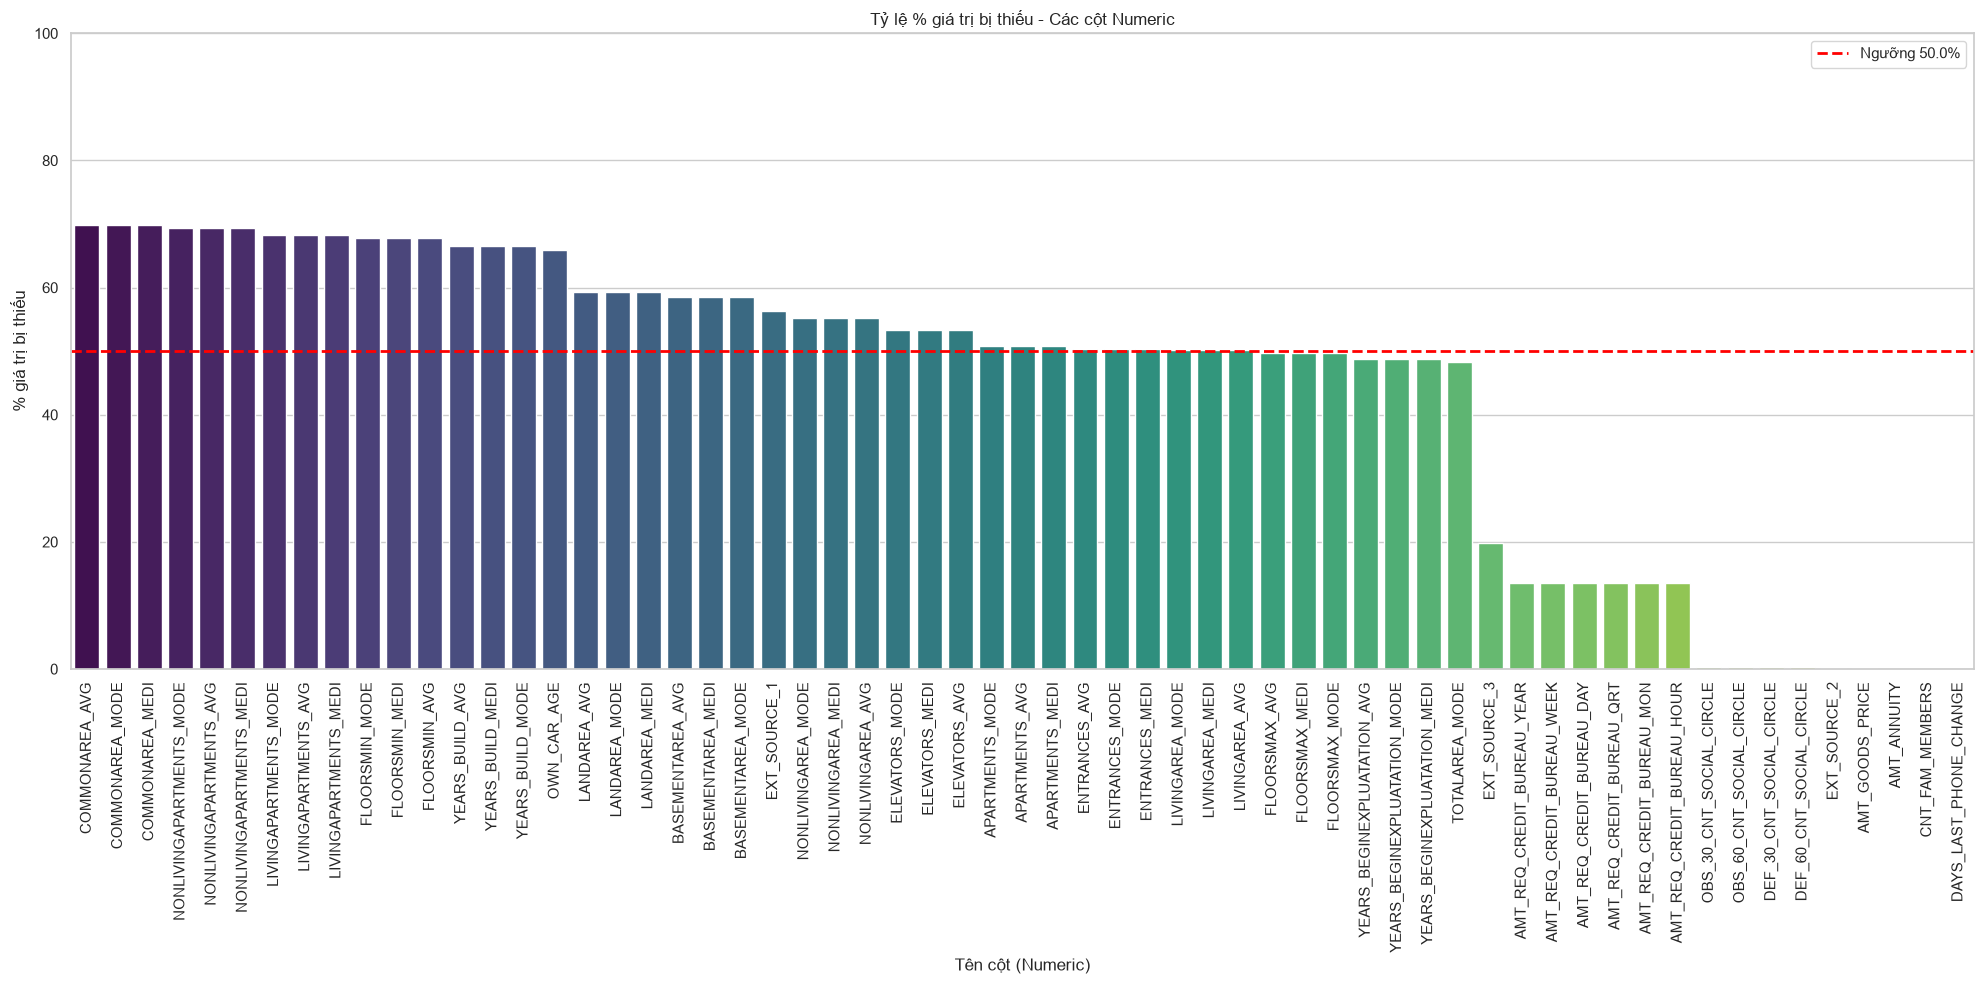

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_25788\2524866422.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_df.index, y=category_df['MissingPercent'], palette="magma")


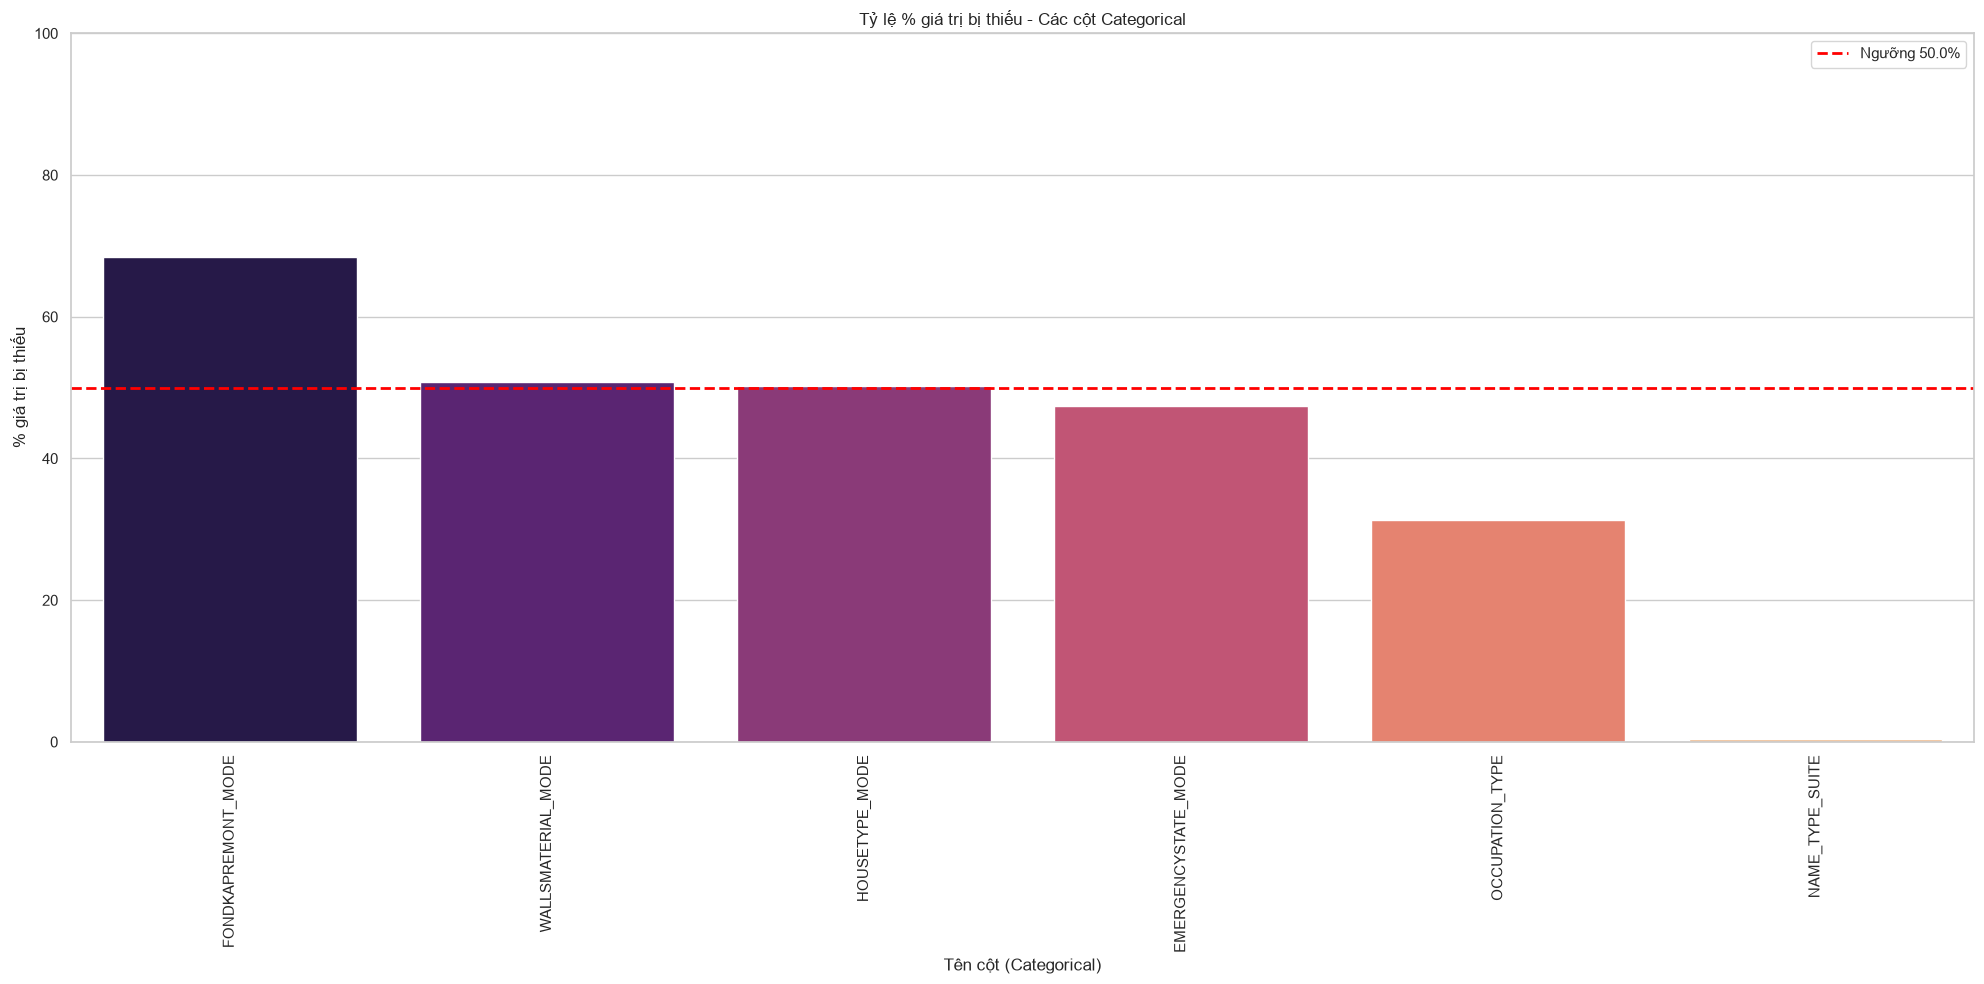

Các cột có tỷ lệ % giá trị bị thiếu >= 50.0%:
- COMMONAREA_AVG (float64): 69.87%
- COMMONAREA_MEDI (float64): 69.87%
- COMMONAREA_MODE (float64): 69.87%
- NONLIVINGAPARTMENTS_AVG (float64): 69.43%
- NONLIVINGAPARTMENTS_MODE (float64): 69.43%
- NONLIVINGAPARTMENTS_MEDI (float64): 69.43%
- FONDKAPREMONT_MODE (str): 68.39%
- LIVINGAPARTMENTS_AVG (float64): 68.35%
- LIVINGAPARTMENTS_MODE (float64): 68.35%
- LIVINGAPARTMENTS_MEDI (float64): 68.35%
- FLOORSMIN_MODE (float64): 67.85%
- FLOORSMIN_MEDI (float64): 67.85%
- FLOORSMIN_AVG (float64): 67.85%
- YEARS_BUILD_MODE (float64): 66.50%
- YEARS_BUILD_MEDI (float64): 66.50%
- YEARS_BUILD_AVG (float64): 66.50%
- OWN_CAR_AGE (float64): 65.99%
- LANDAREA_MODE (float64): 59.38%
- LANDAREA_MEDI (float64): 59.38%
- LANDAREA_AVG (float64): 59.38%
- BASEMENTAREA_MODE (float64): 58.52%
- BASEMENTAREA_AVG (float64): 58.52%
- BASEMENTAREA_MEDI (float64): 58.52%
- EXT_SOURCE_1 (float64): 56.38%
- NONLIVINGAREA_MEDI (float64): 55.18%
- NONLIVINGAREA_AVG (

(                              MissingCount  MissingPercent DataType
 COMMONAREA_AVG                      214865       69.872297  float64
 COMMONAREA_MODE                     214865       69.872297  float64
 COMMONAREA_MEDI                     214865       69.872297  float64
 NONLIVINGAPARTMENTS_MODE            213514       69.432963  float64
 NONLIVINGAPARTMENTS_AVG             213514       69.432963  float64
 NONLIVINGAPARTMENTS_MEDI            213514       69.432963  float64
 LIVINGAPARTMENTS_MODE               210199       68.354953  float64
 LIVINGAPARTMENTS_AVG                210199       68.354953  float64
 LIVINGAPARTMENTS_MEDI               210199       68.354953  float64
 FLOORSMIN_MODE                      208642       67.848630  float64
 FLOORSMIN_MEDI                      208642       67.848630  float64
 FLOORSMIN_AVG                       208642       67.848630  float64
 YEARS_BUILD_AVG                     204488       66.497784  float64
 YEARS_BUILD_MEDI                 

In [58]:
check_and_plot_missing(application_train)

# BÁO CÁO PHÂN TÍCH CHUYÊN SÂU THỰC TRẠNG KHUYẾT THIẾU DỮ LIỆU (DATA MISSINGNESS REPORT)

---

## 1. TỔNG QUAN TÌNH TRẠNG DỮ LIỆU

Tập dữ liệu ghi nhận tình trạng khuyết thiếu nghiêm trọng trên nhiều nhóm thuộc tính khác nhau:
- **Tổng số đặc trưng bị thiếu dữ liệu:** 67 cột (Numeric + Categorical).
- **Tỷ lệ khuyết thiếu dao động:** từ 0.0003% (1 bản ghi) đến 69.87% (214,865 bản ghi).
- **Số lượng thuộc tính vượt ngưỡng khuyết thiếu ≥ 50%:** 41 cột (38 Numeric, 3 Categorical).

---

## 2. PHÂN TÍCH THEO NHÓM ĐẶC TRƯNG

### A. Nhóm Bất động sản / Tòa nhà
- **Numeric (65–70%):** `COMMONAREA_*` (~69.87%), `NONLIVINGAPARTMENTS_*` (~69.43%), `LIVINGAPARTMENTS_*` (~68.35%), `FLOORSMIN_*` (~67.85%), `YEARS_BUILD_*` (~66.50%).
- **Numeric (50–60%):** `LANDAREA_*` (~59.38%), `BASEMENTAREA_*` (~58.52%), `NONLIVINGAREA_*` (~55.18%), `ELEVATORS_*` (~53.30%), `APARTMENTS_*` (~50.75%), `ENTRANCES_*` (~50.35%), `LIVINGAREA_*` (~50.19%).
- **Numeric (48–50%):** `FLOORSMAX_*` (~49.76%), `YEARS_BEGINEXPLUATATION_*` (~48.78%), `TOTALAREA_MODE` (~48.27%).
- **Categorical:**  
  - `FONDKAPREMONT_MODE`: **68.39%**  
  - `WALLSMATERIAL_MODE`: **50.84%**  
  - `HOUSETYPE_MODE`: **50.18%**  
  - `EMERGENCYSTATE_MODE`: **47.40%**

> **Nguyên nhân nghiệp vụ:** Khách hàng không cung cấp thông tin hạ tầng căn hộ nếu không dùng bất động sản làm tài sản thế chấp.

---

### B. Nhóm Điểm số Tín dụng Bên ngoài
- `EXT_SOURCE_1`: **56.38%**  
- `EXT_SOURCE_3`: **19.83%**  
- `EXT_SOURCE_2`: **0.21%**

> **Đánh giá:** `EXT_SOURCE_1` thiếu hơn một nửa dữ liệu, cần xử lý cẩn thận vì có sức mạnh dự báo rủi ro cao.

---

### C. Nhóm Tài sản & Nghề nghiệp
- `OWN_CAR_AGE`: **65.99%** (do khách hàng không sở hữu ô tô → MNAR).  
- `OCCUPATION_TYPE`: **31.35%** (cần kiểm tra trùng khớp với nhóm thất nghiệp/nghỉ hưu).

---

### D. Nhóm Lịch sử Tín dụng & Xã hội
- **CIC (`AMT_REQ_CREDIT_BUREAU_*`):** thiếu đồng loạt **13.50%**.  
- **Mạng xã hội:** `OBS_*_CNT_SOCIAL_CIRCLE`, `DEF_*_CNT_SOCIAL_CIRCLE` thiếu **0.33%**.  
- **Khác:**  
  - `NAME_TYPE_SUITE`: **0.42%**  
  - `AMT_GOODS_PRICE`: **0.09%**  
  - `AMT_ANNUITY`: **0.0039%**  
  - `CNT_FAM_MEMBERS`: **0.00065%**  
  - `DAYS_LAST_PHONE_CHANGE`: **0.000325%**

---

## 3. ĐỀ XUẤT XỬ LÝ DỮ LIỆU

1. **Loại bỏ (Feature Dropping):**  
   - Các cột bất động sản có tỷ lệ thiếu > 50% và ít giá trị dự báo.

2. **Gán theo nghiệp vụ (Domain-Specific):**  
   - `OWN_CAR_AGE`: tạo biến `FLAG_HAS_CAR`, gán Missing = -1 hoặc 0.  
   - `OCCUPATION_TYPE`: gán `'Unspecified'`.

3. **Imputation nâng cao:**  
   - `EXT_SOURCE_1`, `EXT_SOURCE_3`: dùng **IterativeImputer**, **KNNImputer**, hoặc mô hình cây (LightGBM/XGBoost).

4. **Cột thiếu < 1%:**  
   - Gán Median (Numeric) hoặc Mode (Categorical).  
   - Hoặc loại bỏ bản ghi thiếu vì ảnh hưởng không đáng kể.


---
---
# BÁO CÁO PHÂN TÍCH CHUYÊN SÂU THỰC TRẠNG KHUYẾT THIẾU DỮ LIỆU (DATA MISSINGNESS REPORT)

---

## 1. TỔNG QUAN TÌNH TRẠNG DỮ LIỆU

Tập dữ liệu ghi nhận tình trạng khuyết thiếu nghiêm trọng trên nhiều nhóm thuộc tính khác nhau:
* Tổng số đặc trưng bị thiếu dữ liệu: **67 cột** (Bao gồm các cột thuộc cả dạng Numeric và Categorical).
* Tỷ lệ khuyết thiếu dao động rộng: Từ **0.0003%** (1 bản ghi) cho đến cao nhất là **69.87%** (214,865 bản ghi).
* Số lượng thuộc tính vượt ngưỡng khuyết thiếu (>= 50%): **41 cột** (38 cột Numeric và 3 cột Categorical).

---

## 2. PHÂN TÍCH CHI TIẾT THEO CÁC NHÓM ĐẶC TRƯNG

### A. Nhóm thuộc tính Thông tin Bất động sản / Tòa nhà (Real Estate & Building Features)
Đây là nhóm dữ liệu có tỷ lệ khuyết thiếu cao nhất toàn bộ tập dữ liệu (chiếm phần lớn các cột bị thiếu từ 48% đến gần 70%).

1. **Đặc trưng dạng Số (Numeric):**
   * **Mức độ cực cao (65% - 70%):** Các chỉ số diện tích và kết cấu chi tiết như 
    - `COMMONAREA_*` (~69.87%), 
    - `NONLIVINGAPARTMENTS_*` (~69.43%), 
    - `LIVINGAPARTMENTS_*` (~68.35%), 
    - `FLOORSMIN_*` (~67.85%), và 
    - `YEARS_BUILD_*` (~66.50%).
   * **Mức độ cao (50% - 60%):** 
    - `LANDAREA_*` (~59.38%), 
    - `BASEMENTAREA_*` (~58.52%), 
    - `NONLIVINGAREA_*` (~55.18%), 
    - `ELEVATORS_*` (~53.30%), 
    - `APARTMENTS_*` (~50.75%), 
    - `ENTRANCES_*` (~50.35%), 
    - `LIVINGAREA_*` (~50.19%).
   * **Mức độ trung bình (48% - 50%):** 
    -`FLOORSMAX_*` (~49.76%), 
    -`YEARS_BEGINEXPLUATATION_*` (~48.78%), 
    -`TOTALAREA_MODE` (~48.27%).

2. **Đặc trưng dạng Phân loại (Categorical):**
   * `FONDKAPREMONT_MODE` (Chế độ quỹ bảo trì): Thiếu **68.39%** (210,295 bản ghi).
   * `WALLSMATERIAL_MODE` (Vật liệu xây tường): Thiếu **50.84%** (156,341 bản ghi).
   * `HOUSETYPE_MODE` (Loại nhà ở): Thiếu **50.18%** (154,297 bản ghi).
   * `EMERGENCYSTATE_MODE` (Tình trạng khẩn cấp): Thiếu **47.40%** (145,755 bản ghi).

> **Nguyên nhân nghiệp vụ:** Khách hàng nộp hồ sơ vay hầu như không cung cấp hoặc hệ thống không bắt buộc nhập các thông tin chi tiết về hạ tầng căn hộ/tòa nhà nếu họ không sở hữu hoặc không dùng bất động sản đó làm tài sản thế chấp.

---

### B. Nhóm thuộc tính Điểm số Tín dụng Bên ngoài (External Credit Scores)
* **`EXT_SOURCE_1`:** Thiếu **56.38%** (173,378 bản ghi). Đây là biến có tỷ lệ thiếu rất cao trong nhóm biến dự báo rủi ro quan trọng.
* **`EXT_SOURCE_3`:** Thiếu **19.83%** (60,965 bản ghi).
* **`EXT_SOURCE_2`:** Thiếu **0.21%** (660 bản ghi) - Chất lượng dữ liệu rất tốt.

> **Đánh giá:** `EXT_SOURCE_1` thiếu hơn một nửa dữ liệu. Cần cân nhắc phương pháp xử lý cẩn thận vì đây là một trong những đặc trưng có lực phân loại rủi ro (predictive power) mạnh nhất.

---

### C. Nhóm thuộc tính Tài sản & Nghề nghiệp (Personal Assets & Occupation)
* **`OWN_CAR_AGE` (Số tuổi của xe ô tô sở hữu):** Thiếu **65.99%** (202,929 bản ghi).
  * *Lưu ý nghiệp vụ:* Giá trị bị thiếu ở đây nhiều khả năng do khách hàng **không sở hữu ô tô** (MNAR - Missing Not At Random) chứ không hẳn là dữ liệu bị mất mát ngẫu nhiên.
* **`OCCUPATION_TYPE` (Loại hình công việc):** Thiếu **31.35%** (96,391 bản ghi).
  * *Lưu ý:* Cần kiểm tra xem nhóm thiếu này có trùng khớp với nhóm khách hàng thất nghiệp/nghỉ hưu (có `DAYS_EMPLOYED = 365243`) hay không.

---

### D. Nhóm thuộc tính Lịch sử Tín dụng & Xã hội (Credit Bureau & Social Circle)
1. **Lịch sử tra cứu CIC (`AMT_REQ_CREDIT_BUREAU_*`):**
   * Các cột `YEAR`, `WEEK`, `DAY`, `QRT`, `MON`, `HOUR` đều có cùng tỷ lệ khuyết thiếu là **13.50%** (41,519 bản ghi).
   * Sự trùng khớp hoàn toàn về số lượng thiếu cho thấy các biến này bị thiếu đồng thời theo hệ thống (Systematic Missing).

2. **Mạng lưới xã hội (`OBS_*_CNT_SOCIAL_CIRCLE`, `DEF_*_CNT_SOCIAL_CIRCLE`):**
   * Tỷ lệ thiếu rất thấp: **0.33%** (1,021 bản ghi).

3. **Thông tin giao dịch & Nhân thân khác:**
   * `NAME_TYPE_SUITE`: Thiếu **0.42%** (1,292 bản ghi).
   * `AMT_GOODS_PRICE`: Thiếu **0.09%** (278 bản ghi).
   * `AMT_ANNUITY`: Thiếu **0.0039%** (12 bản ghi).
   * `CNT_FAM_MEMBERS`: Thiếu **0.00065%** (2 bản ghi).
   * `DAYS_LAST_PHONE_CHANGE`: Thiếu **0.000325%** (1 bản ghi).

---

## 3. ĐỀ XUẤT HƯỚNG XỬ LÝ DỮ LIỆU (DATA IMPUTATION STRATEGY)

### 1. Loại bỏ thuộc tính (Feature Dropping):
* Đối với các thuộc tính tòa nhà/bất động sản (`COMMONAREA_*`, `NONLIVINGAPARTMENTS_*`, `LIVINGAPARTMENTS_*`...) có tỷ lệ thiếu > 50% và mang ít giá trị dự báo rủi ro cá nhân, nên xem xét **loại bỏ (drop)** để giảm bớt chiều dữ liệu và tránh nhiễu.

### 2. Gán giá trị theo nghiệp vụ (Domain-Specific Imputation):
* **`OWN_CAR_AGE`:** Không nên gán bằng Mean/Median. Nên tạo biến cờ `FLAG_HAS_CAR` (0/1), sau đó với các giá trị Missing của `OWN_CAR_AGE` có thể điền bằng `-1` hoặc `0` để đánh dấu nhóm không có xe.
* **`OCCUPATION_TYPE`:** Điền các giá trị thiếu bằng nhóm danh mục mới gọi là `'Unspecified'` hoặc `'Laborer_Unknown'`.

### 3. Phương pháp gán nâng cao (Advanced Imputation):
* **`EXT_SOURCE_1` và `EXT_SOURCE_3`:** Không nên loại bỏ do tầm quan trọng cao. Sử dụng các thuật toán như **IterativeImputer**, **KNNImputer** hoặc các mô hình cây quyết định (LightGBM/XGBoost) có khả năng tự xử lý giá trị `NaN` trực tiếp trong quá trình huấn luyện.

### 4. Xử lý các cột có tỷ lệ thiếu cực nhỏ (< 1%):
* Đối với các cột như `AMT_ANNUITY`, `CNT_FAM_MEMBERS`, `DAYS_LAST_PHONE_CHANGE`... có thể dùng phương pháp gán đơn giản như **Median** (cho biến số) hoặc **Mode** (cho biến danh mục), hoặc đơn giản là xóa bỏ các bản ghi này mà không làm ảnh hưởng tới kích thước tổng thể của tập dữ liệu.

---
---

In [57]:
check_duplicates(application_train, subset=['SK_ID_CURR'])

BÁO CÁO KIỂM TRA TRÙNG LẶP DỮ LIỆU
- Tổng số dòng trong DataFrame: 307,511
- Kiểm tra trên nhóm cột: ['SK_ID_CURR']
- Số dòng bị trùng lặp: 0 (0.00%)


(np.int64(0),
 Empty DataFrame
 Columns: [SK_ID_CURR, TARGET, NAME_CONTRACT_TYPE, CODE_GENDER, FLAG_OWN_CAR, FLAG_OWN_REALTY, CNT_CHILDREN, AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, AMT_GOODS_PRICE, NAME_TYPE_SUITE, NAME_INCOME_TYPE, NAME_EDUCATION_TYPE, NAME_FAMILY_STATUS, NAME_HOUSING_TYPE, REGION_POPULATION_RELATIVE, DAYS_BIRTH, DAYS_EMPLOYED, DAYS_REGISTRATION, DAYS_ID_PUBLISH, OWN_CAR_AGE, FLAG_MOBIL, FLAG_EMP_PHONE, FLAG_WORK_PHONE, FLAG_CONT_MOBILE, FLAG_PHONE, FLAG_EMAIL, OCCUPATION_TYPE, CNT_FAM_MEMBERS, REGION_RATING_CLIENT, REGION_RATING_CLIENT_W_CITY, WEEKDAY_APPR_PROCESS_START, HOUR_APPR_PROCESS_START, REG_REGION_NOT_LIVE_REGION, REG_REGION_NOT_WORK_REGION, LIVE_REGION_NOT_WORK_REGION, REG_CITY_NOT_LIVE_CITY, REG_CITY_NOT_WORK_CITY, LIVE_CITY_NOT_WORK_CITY, ORGANIZATION_TYPE, EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3, APARTMENTS_AVG, BASEMENTAREA_AVG, YEARS_BEGINEXPLUATATION_AVG, YEARS_BUILD_AVG, COMMONAREA_AVG, ELEVATORS_AVG, ENTRANCES_AVG, FLOORSMAX_AVG, FLOORSMIN_AVG, L

---
---
# BÁO CÁO KIỂM TRA & XỬ LÝ TRÙNG LẶP DỮ LIỆU (DUPLICATE DATA REPORT)

---

## 1. KẾT QUẢ KIỂM TRA TRÙNG LẶP

Qua kiểm tra toàn bộ **307,511 bản ghi** trên tất cả **122 thuộc tính** của tập dữ liệu `application_train`, kết quả ghi nhận:

* **Số lượng dòng bị trùng lặp hoàn toàn (Full Duplicates):** 0 dòng (Tỷ lệ: 0.00%).
* **Đánh giá chất lượng:** Tập dữ liệu đạt tiêu chuẩn cao về tính **Duy nhất (Uniqueness)**. Mỗi dòng biểu diễn chính xác cho một hồ sơ đăng ký vay độc lập, không xảy ra hiện tượng nhân bản dữ liệu (duplicate rows) do lỗi hệ thống hay nhiễu trong quá trình thu thập/truy xuất.

---

## 2. CÁC PHƯƠNG PHÁP XỬ LÝ TRÙNG LẶP DỮ LIỆU CƠ BẢN & NÂNG CAO

Dù tập dữ liệu này hoàn toàn sạch trùng lặp, việc hiểu và sẵn sàng các kịch bản xử lý trùng lặp (Duplicate Handling Strategies) là chuẩn mực quan trọng trong quy trình chuẩn hóa dữ liệu (Data Preprocessing):

### A. Trùng lặp hoàn toàn (Exact / Full Duplicates)
Xảy ra khi hai hay nhiều dòng có giá trị hoàn toàn giống nhau trên **tất cả các cột**.
* **Cách xử lý:** Xóa bỏ (Drop) các dòng lặp lại, chỉ giữ lại bản ghi đầu tiên (`keep='first'`) hoặc bản ghi cuối cùng (`keep='last'`).
* **Mã xử lý (Pandas):**
  ```python
  df_clean = df.drop_duplicates(keep='first')

---
---

- DAYS_EMPLOYED cực kỳ bất thường: Giá trị max lên tới $365,243$ ngày (tương đương 1,000 năm làm việc). Trong bộ dữ liệu Home Credit, giá trị 365243 là mã hóa đặc biệt đại diện cho người thất nghiệp hoặc đã nghỉ hưu.
- DAYS_BIRTH dương hoặc lớn hơn 0: DAYS_BIRTH ghi nhận số ngày đếm ngược từ ngày nộp hồ sơ, nên tất cả giá trị phải $\le 0$. Nếu $>0$ là sai logic.
- CNT_CHILDREN > CNT_FAM_MEMBERS: Số con không thể nhiều hơn tổng số thành viên trong gia đình.
- AMT_ANNUITY > AMT_CREDIT: Khoản trả góp hàng năm không thể lớn hơn tổng số tiền vay (trừ trường hợp cực kỳ hiếm với lãi phạt khủng khiếp, nhưng với vay tiêu dùng ngắn hạn thông thường thì đây là lỗi dữ liệu).
- OWN_CAR_AGE < 0 hoặc > 80: Tuổi xe hơi bị âm hoặc lớn hơn 80-100 năm.Cột binary (FLAG_..., TARGET) nằm ngoài khoảng [0, 1].

In [99]:
check_logical_errors(application_train)

BÁO CÁO KIỂM TRA LỖI LOGIC DỮ LIỆU


,Lỗi logic / Quy tắc,Số dòng vi phạm,Tỷ lệ (%),Mô tả
0,DAYS_EMPLOYED == 365243,55374,18.0072,Giá trị dị biệt đại diện cho Thất nghiệp/Nghỉ ...
1,DAYS_EMPLOYED > 0 (Dương bất thường),0,0.0000,Số ngày làm việc dương (ngoại trừ 365243)
2,DAYS_BIRTH > 0,0,0.0000,Ngày sinh là giá trị dương (chưa sinh ra)
3,CNT_CHILDREN > CNT_FAM_MEMBERS,0,0.0000,Số con nhiều hơn tổng số thành viên gia đình
4,AMT_ANNUITY > AMT_CREDIT,0,0.0000,Tiền trả góp hàng năm lớn hơn tổng số tiền vay
5,OWN_CAR_AGE bất thường,2,0.0007,Tuổi xe bị âm hoặc lớn hơn 80 năm
6,Cột FLAG_OWN_CAR không hợp lệ,307511,100.0000,"Giá trị nằm ngoài khoảng [0, 1]"
7,Cột FLAG_OWN_REALTY không hợp lệ,307511,100.0000,"Giá trị nằm ngoài khoảng [0, 1]"
8,HOUR_APPR_PROCESS_START ngoài [0-23],0,0.0000,Khung giờ không hợp lệ


In [116]:
check_logical_errors_v2(application_train)

--- QUÉT CÁC CỘT NHỊ PHÂN (NUNIQUE == 2) ---
Phát hiện 11 quy tắc bị vi phạm.


,Lỗi logic / Quy tắc,Số dòng vi phạm,Tỷ lệ (%),Mô tả
0,Cột nhị phân `NAME_CONTRACT_TYPE` sai định dạn...,307511,100.0000,"Cột có 2 giá trị là ['Revolving loans', 'Cash ..."
1,"Cột nhị phân `FLAG_OWN_CAR` sai định dạng [0, 1]",307511,100.0000,"Cột có 2 giá trị là ['N', 'Y'], không thuộc bộ..."
2,Cột nhị phân `FLAG_OWN_REALTY` sai định dạng [...,307511,100.0000,"Cột có 2 giá trị là ['N', 'Y'], không thuộc bộ..."
3,Cột nhị phân `EMERGENCYSTATE_MODE` sai định dạ...,161756,52.6017,"Cột có 2 giá trị là ['Yes', 'No'], không thuộc..."
4,DAYS_EMPLOYED == 365243,55374,18.0072,Giá trị dị biệt đại diện cho Thất nghiệp/Nghỉ ...
5,DAYS_EMPLOYED > 0 (Dương bất thường),0,0.0000,Số ngày làm việc dương (ngoại trừ 365243)
6,DAYS_BIRTH > 0,0,0.0000,Ngày sinh là giá trị dương (chưa sinh ra)
7,CNT_CHILDREN > CNT_FAM_MEMBERS,0,0.0000,Số con nhiều hơn tổng số thành viên gia đình
8,AMT_ANNUITY > AMT_CREDIT,0,0.0000,Tiền trả góp hàng năm lớn hơn tổng số tiền vay
9,OWN_CAR_AGE bất thường,2,0.0007,Tuổi xe bị âm hoặc lớn hơn 80 năm


---
---

BÁO CÁO KHÁM PHÁ DỮ LIỆU TỰ ĐỘNG - Tổng số dòng: 307,511

1. BÁO CÁO BIẾN MỤC TIÊU (TARGET: 'TARGET')
------------------------------------------------------------
- Số lượng Missing: 0 (0.00%)
- Phân bố giá trị:
        Số lượng  Tỷ lệ (%)
TARGET                     
0         282686  91.927118
1          24825   8.072882


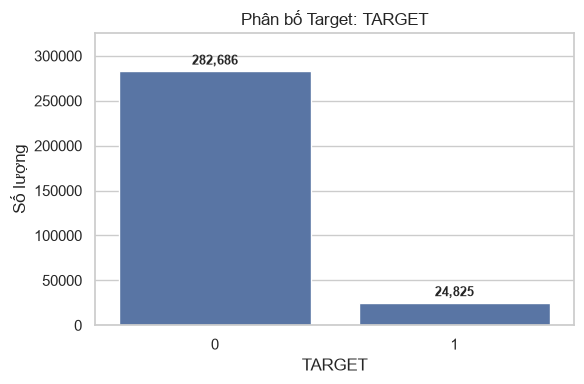

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_25788\1149082825.py:225: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(feature_df[col]) or pd.api.types.is_bool_dtype(feature_df[col]):



3. BÁO CÁO CỘT PHÂN LOẠI (CATEGORY) - [16 cột]
------------------------------------------------------------

>>> Nhóm kiểu dữ liệu [STR] - Total: 16 cột
- Cột: `NAME_CONTRACT_TYPE` | Số nhóm: 2 | Missing: 0
  Top 5 giá trị:
NAME_CONTRACT_TYPE  Cash loans  Revolving loans
Số lượng                278232            29279
- Cột: `CODE_GENDER` | Số nhóm: 3 | Missing: 0
  Top 5 giá trị:
CODE_GENDER       F       M  XNA
Số lượng     202448  105059    4
- Cột: `FLAG_OWN_CAR` | Số nhóm: 2 | Missing: 0
  Top 5 giá trị:
FLAG_OWN_CAR       N       Y
Số lượng      202924  104587
- Cột: `FLAG_OWN_REALTY` | Số nhóm: 2 | Missing: 0
  Top 5 giá trị:
FLAG_OWN_REALTY       Y      N
Số lượng         213312  94199
- Cột: `NAME_TYPE_SUITE` | Số nhóm: 7 | Missing: 1,292
  Top 5 giá trị:
NAME_TYPE_SUITE  Unaccompanied  Family  Spouse, partner  Children  Other_B
Số lượng                248526   40149            11370      3267     1770
- Cột: `NAME_INCOME_TYPE` | Số nhóm: 8 | Missing: 0
  Top 5 giá trị:
NAME_

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_25788\1149082825.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vc.index.astype(str), y=top_vc.values, palette='mako', ax=ax)
C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_25788\1149082825.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vc.index.astype(str), y=top_vc.values, palette='mako', ax=ax)
C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_25788\1149082825.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vc.index.astype(str), y=top_vc.values, palette='mako',

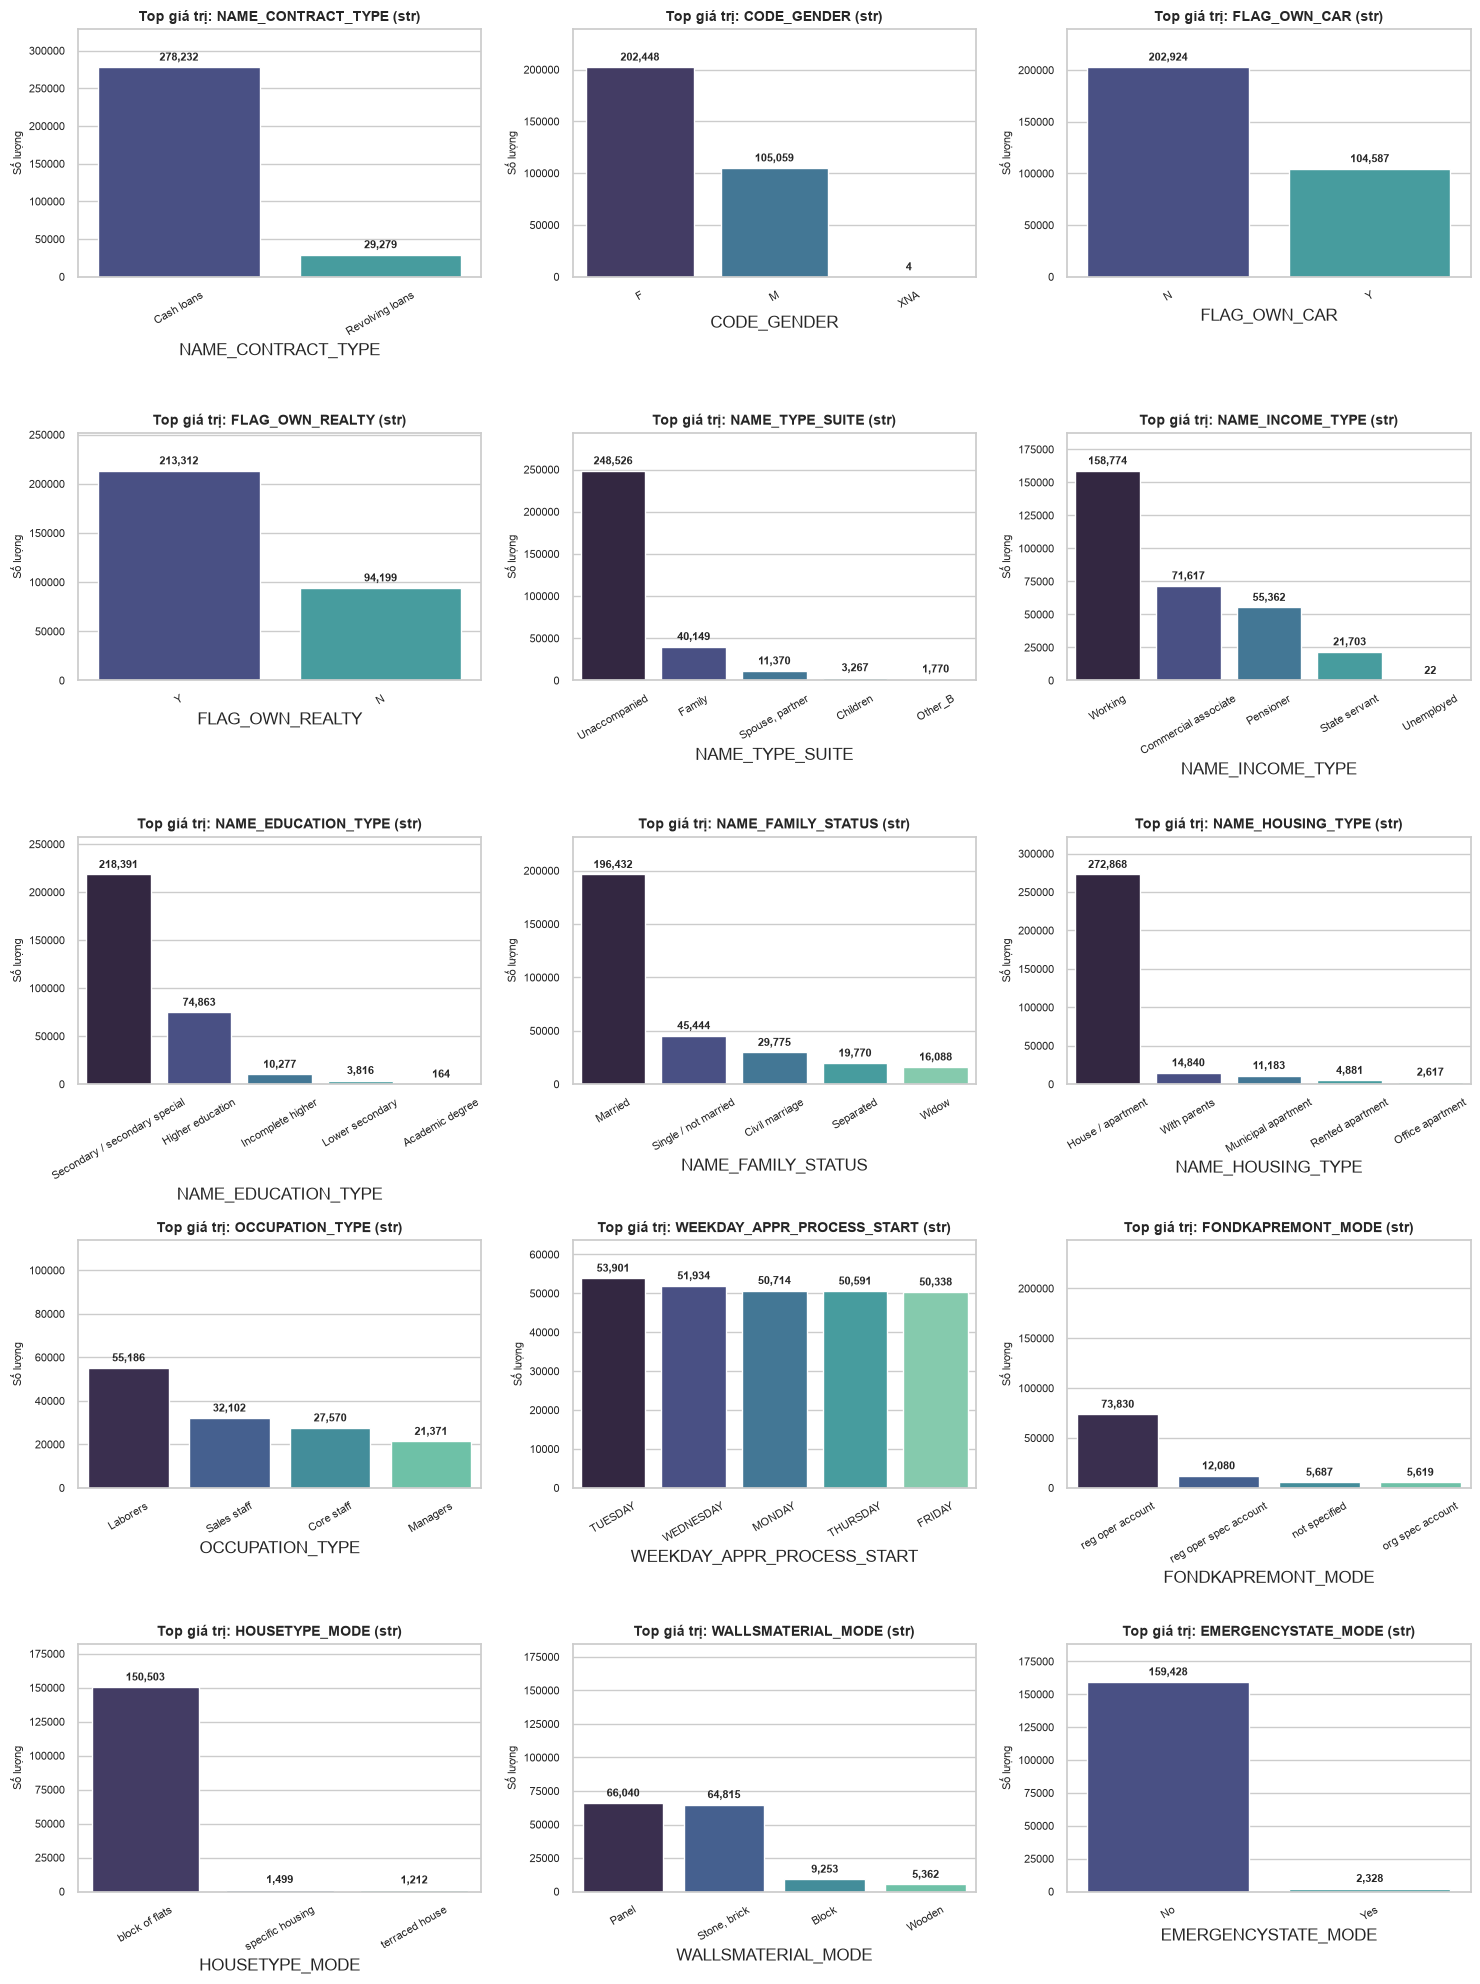


4. BÁO CÁO CỘT DẠNG SỐ (NUMERIC) - [105 cột]
------------------------------------------------------------
                                 count  missing           mean            std           min            25%            50%            75%           max
SK_ID_CURR                    307511.0        0  278180.518577  102790.175348  1.000020e+05  189145.500000  278202.000000  367142.500000  4.562550e+05
CNT_CHILDREN                  307511.0        0       0.417052       0.722121  0.000000e+00       0.000000       0.000000       1.000000  1.900000e+01
AMT_INCOME_TOTAL              307511.0        0  168797.919297  237123.146279  2.565000e+04  112500.000000  147150.000000  202500.000000  1.170000e+08
AMT_CREDIT                    307511.0        0  599025.999706  402490.776996  4.500000e+04  270000.000000  513531.000000  808650.000000  4.050000e+06
AMT_ANNUITY                   307499.0       12   27108.573909   14493.737315  1.615500e+03   16524.000000   24903.000000   34596.000000  

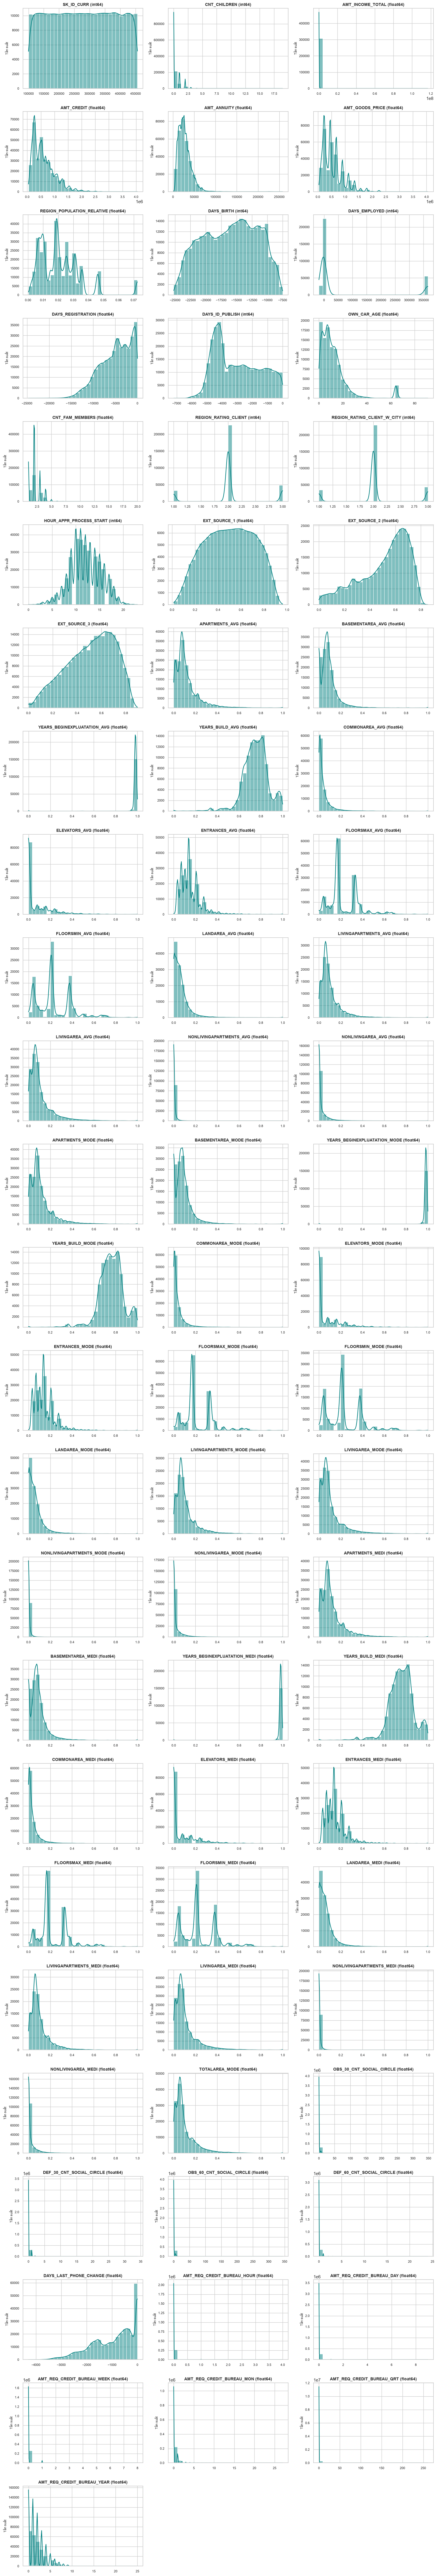

In [117]:
auto_eda_report(application_train, target_col='TARGET')

# PHÂN TÍCH & WORKFLOW XỬ LÝ DỮ LIỆU HOME CREDIT

## 1. Insight Chi tiết từ Biểu đồ

### A. Nhóm Categorical (Phân loại)
* **High Class Imbalance (Mất cân bằng lớp nặng):**
  * `NAME_CONTRACT_TYPE`: Cash loans chiếm đa số (~278k) vs Revolving loans (~25k).
  * `NAME_HOUSING_TYPE` & `HOUSETYPE_MODE`: >85% tập trung ở *House / apartment* & *block of flats*.
  * `EMERGENCYSTATE_MODE`: Giá trị "No" áp đảo hoàn toàn.
* **Đặc trưng Nhân khẩu & Tài chính:**
  * **Giới tính:** Nữ giới (~202k) gấp đôi Nam (~105k).
  * **Tài sản:** Đa số **không** sở hữu ô tô (`FLAG_OWN_CAR` = N), nhưng **có** sở hữu BĐS (`FLAG_OWN_REALTY` = Y).
  * **Học vấn & Nghề nghiệp:** Chủ yếu trình độ Trung học (`Secondary`), nghề nghiệp đông nhất là *Laborers* và *Sales staff*.
  * **Nguồn thu nhập:** Nhóm *Working* và *Commercial associate* chiếm tỷ trọng chính.

### B. Nhóm Numeric (Số)
* **Right-Skewed & High Kurtosis:** Các biến tài chính (`AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`, chỉ số CIC) bị lệch phải nặng; đỉnh tập trung dày đặc ở giá trị 0.
* **Anomalies (Bất thường):** Dữ liệu xuất hiện mã hóa dị biệt (như `DAYS_EMPLOYED = 365243` đại diện cho Missing) và phân phối đa đỉnh (Multimodal).

---

## 2. Giả định ngầm & Rủi ro Tiềm ẩn (Critical View)

* **Sampling Bias (Thiên kiến mẫu):** Tệp khách hàng mang đặc thù riêng của Home Credit (nhiều nữ, có BĐS). Mô hình sẽ không generalize được cho vay thế chấp lớn hoặc tín dụng doanh nghiệp.
* **Low Variance Features (Biến ít biến thiên):** Các cột như `EMERGENCYSTATE_MODE`, `HOUSETYPE_MODE` bị thống trị bởi 1 nhãn $\rightarrow$ Cung cấp ít Information Gain, gây lãng phí bộ nhớ.
* **Skewness thao túng Linear Models:** Nếu dùng Logistic Regression, SVM hay KNN mà không transform dữ liệu, Outliers ở đuôi phải sẽ làm lệch mô hình.
* **MNAR (Missing Not At Random):** Histogram chỉ vẽ trên `.dropna()` giấu đi thực tế nhóm biến Housing thiếu từ 40% - 70%. Missing mang tính hệ thống chứ không ngẫu nhiên.

---

## 3. Workflow Hành động (Actionable Next Steps)

1. **Numeric Preprocessing:**
   * Thay giá trị dị biệt hệ thống (VD: `365243` $\rightarrow$ `np.nan`).
   * Áp dụng `np.log1p` hoặc `QuantileTransformer` cho biến tài chính có Skewness > 1.0.
2. **Category Encoding:** Gom các nhãn hiếm (<1-2% như *Academic degree*, *Unemployed*) vào nhóm `Other` để giảm độ thưa (sparsity).
3. **Feature Selection:** Loại bỏ biến đơn điệu (>95% chứa 1 giá trị) hoặc biến thiếu >50% dữ liệu.
4. **Model Selection:** Ưu tiên **Tree-based Models (LightGBM, XGBoost, CatBoost)** — tự xử lý tốt Missing values, kháng Outliers và không bị ảnh hưởng bởi Skewness.

----
---


In [119]:
inspect_dataframe(bureau)

 BÁO CÁO TỔNG QUAN: [DATAFRAME]
 Kích thước: 1,716,428 dòng x 17 cột

--- 1. XEM 5 DÒNG ĐẦU DỮ LIỆU ---


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN



--- Danh sách tất cả các cột ---
['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']

--- 2. TỔNG HỢP KIỂU DỮ LIỆU ---
float64    8
int64      6
str        3

--- 4. KIỂM TRA DUPLICATES & MISSING VALUES ---
* Số lượng dòng trùng lặp (Duplicates): 0 (0.00%)

* Có 7/17 cột chứa giá trị Missing:


,Kiểu dữ liệu,Số lượng Missing,Tỷ lệ Missing (%)
AMT_ANNUITY,float64,1226791,71.473490
AMT_CREDIT_MAX_OVERDUE,float64,1124488,65.513264
DAYS_ENDDATE_FACT,float64,633653,36.916958
AMT_CREDIT_SUM_LIMIT,float64,591780,34.477415
AMT_CREDIT_SUM_DEBT,float64,257669,15.011932
DAYS_CREDIT_ENDDATE,float64,105553,6.149573
AMT_CREDIT_SUM,float64,13,0.000757



--- 3. THỐNG KÊ MÔ TẢ (NUMERIC FEATURES) ---


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,1716428.0,2.782149e+05,1.029386e+05,100001.000,188866.75,278055.0,367426.00,4.562550e+05
SK_ID_BUREAU,1716428.0,5.924434e+06,5.322657e+05,5000000.000,5463953.75,5926303.5,6385681.25,6.843457e+06
DAYS_CREDIT,1716428.0,-1.142108e+03,7.951649e+02,-2922.000,-1666.00,-987.0,-474.00,0.000000e+00
CREDIT_DAY_OVERDUE,1716428.0,8.181666e-01,3.654443e+01,0.000,0.00,0.0,0.00,2.792000e+03
DAYS_CREDIT_ENDDATE,1610875.0,5.105174e+02,4.994220e+03,-42060.000,-1138.00,-330.0,474.00,3.119900e+04
DAYS_ENDDATE_FACT,1082775.0,-1.017437e+03,7.140106e+02,-42023.000,-1489.00,-897.0,-425.00,0.000000e+00
AMT_CREDIT_MAX_OVERDUE,591940.0,3.825418e+03,2.060316e+05,0.000,0.00,0.0,0.00,1.159872e+08
CNT_CREDIT_PROLONG,1716428.0,6.410406e-03,9.622391e-02,0.000,0.00,0.0,0.00,9.000000e+00
AMT_CREDIT_SUM,1716415.0,3.549946e+05,1.149811e+06,0.000,51300.00,125518.5,315000.00,5.850000e+08
AMT_CREDIT_SUM_DEBT,1458759.0,1.370851e+05,6.774011e+05,-4705600.320,0.00,0.0,40153.50,1.701000e+08



--- 5. PHÂN TÍCH CÁC CỘT PHÂN LOẠI (CATEGORICAL) ---


C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_25788\2505744632.py:59: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns


,Cột,Số giá trị duy nhất (Unique),Giá trị xuất hiện nhiều nhất (Mode),Tần suất Mode,Tỷ lệ Mode (%)
0,CREDIT_ACTIVE,4,Closed,1079273,62.88
1,CREDIT_CURRENCY,4,currency 1,1715020,99.92
2,CREDIT_TYPE,15,Consumer credit,1251615,72.92



--- 6. DUNG LƯỢNG BỘ NHỚ (MEMORY USAGE) ---
* Bộ nhớ đang tiêu tốn: 472.82 MB


---
---
# BÁO CÁO PHÂN TÍCH VÀ ĐÁNH GIÁ DỮ LIỆU (EDA REPORT) CHO FILE bureau.csv
**Tập dữ liệu:** `bureau.csv` (Lịch sử tín dụng tại các tổ chức khác)

---

## 1. TỔNG QUAN VỀ TỆP DỮ LIỆU (DATA OVERVIEW)

| Chỉ số | Giá trị | Ghi chú / Đánh giá |
| :--- | :--- | :--- |
| **Số lượng bản ghi (Rows)** | $1,716,428$ | Quy mô dữ liệu lớn, mối quan hệ 1-N với `SK_ID_CURR` |
| **Số lượng biến (Columns)** | $17$ | 8 `float64`, 6 `int64`, 3 `object/string` |
| **Dung lượng bộ nhớ** | **472.82 MB** | Cần tối ưu dung lượng nếu xử lý RAM hạn chế |
| **Dòng trùng lặp (Duplicates)** | **0 (0.00%)** | Dữ liệu sạch, không bị trùng bản ghi |
| **Số cột chứa Missing Values** | **7 / 17 cột** | Tỷ lệ khuyết thiếu cao ở một số biến tài chính |

---

## 2. BÁO CÁO THỐNG KÊ CHI TIẾT

### A. Tình trạng Dữ liệu Khuyết (Missing Values)

| Tên biến | Kiểu dữ liệu | Số lượng Missing | Tỷ lệ Missing (%) | Mức độ nghiêm trọng & Bản chất |
| :--- | :---: | :---: | :---: | :--- |
| `AMT_ANNUITY` | `float64` | $1,226,791$ | **71.47%** | **Cực cao:** Rất ít dữ liệu về khoản trả hàng tháng lịch sử |
| `AMT_CREDIT_MAX_OVERDUE` | `float64` | $1,124,488$ | **65.51%** | **Rất cao:** Chỉ ghi nhận khi có quá hạn |
| `DAYS_ENDDATE_FACT` | `float64` | $633,653$ | **36.92%** | **Trung bình:** Khuyết do khoản vay vẫn đang mở (`Active`) |
| `AMT_CREDIT_SUM_LIMIT` | `float64` | $591,780$ | **34.48%** | **Trung bình:** Khuyết ở các hợp đồng vay không có hạn mức |
| `AMT_CREDIT_SUM_DEBT` | `float64` | $257,669$ | **15.01%** | **Thấp:** Không ghi nhận dư nợ |
| `DAYS_CREDIT_ENDDATE` | `float64` | $105,553$ | **6.15%** | **Rất thấp:** Thiếu ngày đáo hạn dự kiến |
| `AMT_CREDIT_SUM` | `float64` | $13$ | **0.00%** | Không đáng kể |

---

### B. Biến Phân loại (Categorical Features)

| Tên biến | Số lượng Unique | Giá trị xuất hiện nhiều nhất (Mode) | Tần suất Mode | Tỷ lệ Mode (%) | Đánh giá kỹ thuật |
| :--- | :---: | :--- | :---: | :---: | :--- |
| `CREDIT_CURRENCY` | 4 | `currency 1` | $1,715,020$ | **99.92%** | **Low Variance:** Đơn điệu, không có thông tin phân tách |
| `CREDIT_TYPE` | 15 | `Consumer credit` | $1,251,615$ | **72.92%** | Chiếm đa số là tín dụng tiêu dùng |
| `CREDIT_ACTIVE` | 4 | `Closed` | $1,079,273$ | **62.88%** | Đa số khoản vay trong quá khứ đã tất toán |

---

### C. Phân phối & Biến số Bất thường (Numeric Anomalies & Outliers)

| Tên biến | Giá trị Nhỏ nhất (Min) | Giá trị Trung bình (Mean) | Giá trị Trung vị (Median) | Giá trị Lớn nhất (Max) | Phát hiện Bất thường (Anomaly / Outlier) |
| :--- | :---: | :---: | :---: | :---: | :--- |
| `AMT_CREDIT_SUM` | $0.0$ | $354,994.6$ | $125,518.5$ | $585,000,000.0$ | Outlier cực đoan ở đuôi phải ($Max \gg Median$) |
| `AMT_CREDIT_SUM_DEBT` | **$-4,705,600.3$** | $137,085.1$ | $0.0$ | $170,100,000.0$ | **Lỗi hệ thống:** Dư nợ bị âm sâu bất thường |
| `AMT_CREDIT_SUM_LIMIT` | **$-586,406.1$** | $6,229.5$ | $0.0$ | $4,705,600.0$ | **Lỗi hệ thống:** Hạn mức tín dụng bị âm |
| `DAYS_CREDIT_ENDDATE` | $-42,060.0$ | $510.5$ | $-330.0$ | **$31,199.0$** | **Mã hóa nhiễu:** Số ngày dương $>30,000$ (tương đương ~85 năm) |
| `CREDIT_DAY_OVERDUE` | $0.0$ | $0.82$ | $0.0$ | $2,792.0$ | Bị Skewed nặng, đa số tập trung ở mức 0 ngày |

---

## 3. ĐÁNH GIÁ ĐIỂM YẾU VÀ RỦI RO (CRITICAL RISKS)

1. **Rủi ro Biến Đơn điệu (Zero Information Gain):** 
   * `CREDIT_CURRENCY` chứa $99.92\%$ dữ liệu cùng 1 nhãn. Cột này gây lãng phí tài nguyên tính toán mà không hỗ trợ dự báo nợ xấu.
2. **Hiện tượng Bị lệch nặng (Extreme Skewness & Kurtosis):**
   * Các biến số tài chính (`AMT_CREDIT_SUM`, `AMT_CREDIT_MAX_OVERDUE`) có chênh lệch giữa $Mean$ và $Median$ cực lớn. Nếu đưa vào mô hình Linear/Distance-based sẽ bị Outliers thao túng.
3. **Mã lỗi và Dữ liệu Âm phi lý:**
   * Dư nợ âm (`AMT_CREDIT_SUM_DEBT < 0`) và số ngày đáo hạn $31,199$ ngày là dạng dữ liệu nhiễu do mã hóa từ hệ thống Core-banking cũ.
4. **Mất cân bằng dữ liệu khuyết (MNAR - Missing Not At Random):**
   * Việc khuyết $>71\%$ ở `AMT_ANNUITY` và $>65\%$ ở `AMT_CREDIT_MAX_OVERDUE` xuất phát từ việc tổ chức tín dụng khác không chia sẻ đủ thông tin, không phải mất ngẫu nhiên.

---



## 4. KHUYẾN NGHỊ HÀNH ĐỘNG (ACTIONABLE NEXT STEPS)
```text
[Dữ liệu Thô (Bureau)]
│
├── 1. Drop Cột: Loại bỏ 'CREDIT_CURRENCY'
│
├── 2. Cleaning:
│       ├── 'DAYS_CREDIT_ENDDATE' > 10,000 ────────> Gán np.nan
│       └── Các biến Nợ/Hạn mức âm (< 0) ─────────> Gán 0
│
├── 3. Feature Engineering (Aggregate theo SK_ID_CURR):
│       ├── Count: Tổng số khoản vay cũ
│       ├── Mean/Sum: Tổng dư nợ hiện tại, tổng hạn mức
│       └── Ratio: Tỷ lệ khoản vay đang Active / Total
│
└── 4. Model Selection: Ưu tiên LightGBM / XGBoost / CatBoost
```
| Bước | Hành động cụ thể | Mục đích |
| :---: | :--- | :--- |
| **1** | **Drop biến:** `df.drop(columns=['CREDIT_CURRENCY'])` | Loại bỏ nhiễu và giảm dung lượng RAM |
| **2** | **Xử lý Anomaly:** <br>• Chuyển `DAYS_CREDIT_ENDDATE > 10000` thành `np.nan`<br>• Clip các giá trị dư nợ âm `< 0` về `0` | Tránh làm sai lệch các phép tính toán thống kê ($Mean, Sum$) |
| **3** | **Tạo biến tổng hợp (Gom nhóm theo `SK_ID_CURR`):**<br>• `COUNT(SK_ID_BUREAU)`: Tổng số khoản vay lịch sử<br>• `SUM(AMT_CREDIT_SUM_DEBT)`: Tổng nợ hiện tại<br>• `MAX(CREDIT_DAY_OVERDUE)`: Số ngày quá hạn lớn nhất | Chuyển đổi mối quan hệ 1-N về 1-1 để join vào bảng chính `application_train` |
| **4** | **Lựa chọn Mô hình:** Ưu tiên thuật toán **Gradient Boosting (LightGBM/CatBoost)
** | Kháng Outliers, tự xử lý giá trị `NaN` ở các cột khuyết thiếu $>60\%$ mà không cần Imputation phức tạp |

---
---

In [131]:
inspect_dataframe(credit_card_balance)

 BÁO CÁO TỔNG QUAN: [DATAFRAME]
 Kích thước: 3,840,312 dòng x 23 cột

--- 1. XEM 5 DÒNG ĐẦU DỮ LIỆU ---


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,1800.0,1800.0,0.000,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,2250.0,2250.0,60175.080,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,2250.0,2250.0,26926.425,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,11925.0,11925.0,224949.285,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,27000.0,27000.0,443044.395,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0



--- Danh sách tất cả các cột ---
['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'CNT_INSTALMENT_MATURE_CUM', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']

--- 2. TỔNG HỢP KIỂU DỮ LIỆU ---
float64    15
int64       7
str         1

--- 4. KIỂM TRA DUPLICATES & MISSING VALUES ---
* Số lượng dòng trùng lặp (Duplicates): 0 (0.00%)

* Có 9/23 cột chứa giá trị Missing:


,Kiểu dữ liệu,Số lượng Missing,Tỷ lệ Missing (%)
AMT_PAYMENT_CURRENT,float64,767988,19.998063
AMT_DRAWINGS_ATM_CURRENT,float64,749816,19.524872
AMT_DRAWINGS_OTHER_CURRENT,float64,749816,19.524872
AMT_DRAWINGS_POS_CURRENT,float64,749816,19.524872
CNT_DRAWINGS_ATM_CURRENT,float64,749816,19.524872
CNT_DRAWINGS_POS_CURRENT,float64,749816,19.524872
CNT_DRAWINGS_OTHER_CURRENT,float64,749816,19.524872
AMT_INST_MIN_REGULARITY,float64,305236,7.948208
CNT_INSTALMENT_MATURE_CUM,float64,305236,7.948208



--- 3. THỐNG KÊ MÔ TẢ (NUMERIC FEATURES) ---


,count,mean,std,min,25%,50%,75%,max
SK_ID_PREV,3840312.0,1.904504e+06,536469.470563,1000018.000,1434385.00,1897122.0,2.369328e+06,2843496.000
SK_ID_CURR,3840312.0,2.783242e+05,102704.475133,100006.000,189517.00,278396.0,3.675800e+05,456250.000
MONTHS_BALANCE,3840312.0,-3.452192e+01,26.667751,-96.000,-55.00,-28.0,-1.100000e+01,-1.000
AMT_BALANCE,3840312.0,5.830016e+04,106307.031024,-420250.185,0.00,0.0,8.904669e+04,1505902.185
AMT_CREDIT_LIMIT_ACTUAL,3840312.0,1.538080e+05,165145.699525,0.000,45000.00,112500.0,1.800000e+05,1350000.000
AMT_DRAWINGS_ATM_CURRENT,3090496.0,5.961325e+03,28225.688578,-6827.310,0.00,0.0,0.000000e+00,2115000.000
AMT_DRAWINGS_CURRENT,3840312.0,7.433388e+03,33846.077333,-6211.620,0.00,0.0,0.000000e+00,2287098.315
AMT_DRAWINGS_OTHER_CURRENT,3090496.0,2.881696e+02,8201.989345,0.000,0.00,0.0,0.000000e+00,1529847.000
AMT_DRAWINGS_POS_CURRENT,3090496.0,2.968805e+03,20796.887047,0.000,0.00,0.0,0.000000e+00,2239274.160
AMT_INST_MIN_REGULARITY,3535076.0,3.540204e+03,5600.154122,0.000,0.00,0.0,6.633911e+03,202882.005



--- 5. PHÂN TÍCH CÁC CỘT PHÂN LOẠI (CATEGORICAL) ---


C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_25788\2505744632.py:59: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns


,Cột,Số giá trị duy nhất (Unique),Giá trị xuất hiện nhiều nhất (Mode),Tần suất Mode,Tỷ lệ Mode (%)
0,NAME_CONTRACT_STATUS,7,Active,3698436,96.31



--- 6. DUNG LƯỢNG BỘ NHỚ (MEMORY USAGE) ---
* Bộ nhớ đang tiêu tốn: 846.39 MB


# BÁO CÁO PHÂN TÍCH VÀ ĐÁNH GIÁ DỮ LIỆU (EDA REPORT) credit_card_balance.csv
**Tập dữ liệu:** `credit_card_balance.csv` (Lịch sử dư nợ và giao dịch thẻ tín dụng hàng tháng)

---

## 1. TỔNG QUAN VỀ TỆP DỮ LIỆU (DATA OVERVIEW)

| Chỉ số | Giá trị | Ghi chú / Đánh giá |
| :--- | :--- | :--- |
| **Số lượng bản ghi (Rows)** | $3,840,312$ | Dữ liệu dạng time-series theo tháng của thẻ tín dụng |
| **Số lượng biến (Columns)** | $23$ | 15 `float64`, 7 `int64`, 1 `object/string` |
| **Dung lượng bộ nhớ** | **846.39 MB** | Dung lượng khá lớn, cần xem xét downcast kiểu dữ liệu khi train |
| **Dòng trùng lặp (Duplicates)** | **0 (0.00%)** | Dữ liệu sạch, không có bản ghi trùng hoàn toàn |
| **Số cột chứa Missing Values** | **9 / 23 cột** | Tập trung khuyết ở nhóm cột chi tiết rút tiền/giao dịch |

---

## 2. GIẢI THÍCH Ý NGHĨA CÁC CỘT DỮ LIỆU (FEATURE DICTIONARY)

| STT | Tên cột (Feature) | Kiểu dữ liệu | Ý nghĩa Nghiệp vụ / Mô tả |
| :---: | :--- | :---: | :--- |
| 1 | `SK_ID_PREV` | `int64` | ID của khoản vay/hợp đồng thẻ tín dụng cũ |
| 2 | `SK_ID_CURR` | `int64` | ID của khách hàng trong hồ sơ hiện tại |
| 3 | `MONTHS_BALANCE` | `int64` | Số tháng tính từ thời điểm nộp hồ sơ hiện tại (VD: -1 là tháng trước) |
| 4 | `AMT_BALANCE` | `float64` | Số dư nợ thẻ tín dụng trong tháng |
| 5 | `AMT_CREDIT_LIMIT_ACTUAL` | `int64` | Hạn mức thẻ tín dụng thực tế được cấp |
| 6 | `AMT_DRAWINGS_ATM_CURRENT` | `float64` | Số tiền rút mặt tại cây ATM trong tháng |
| 7 | `AMT_DRAWINGS_CURRENT` | `float64` | **Tổng số tiền đã rút/chi tiêu** từ thẻ trong tháng |
| 8 | `AMT_DRAWINGS_OTHER_CURRENT` | `float64` | Số tiền chi tiêu/rút qua các hình thức khác |
| 9 | `AMT_DRAWINGS_POS_CURRENT` | `float64` | Số tiền quẹt thẻ thanh toán tại máy POS |
| 10 | `AMT_INST_MIN_REGULARITY` | `float64` | Số tiền thanh toán tối thiểu bắt buộc của kỳ đó |
| 11 | `AMT_PAYMENT_CURRENT` | `float64` | Số tiền khách hàng đã thực trả trong tháng |
| 12 | `AMT_PAYMENT_TOTAL_CURRENT` | `float64` | Tổng số tiền khách hàng đã trả (bao gồm cả phí/lãi) |
| 13 | `AMT_RECEIVABLE_PRINCIPAL` | `float64` | Dư nợ gốc còn phải thu |
| 14 | `AMT_RECIVABLE` | `float64` | Dư nợ còn phải thu (Gốc + Phí + Lãi) |
| 15 | `AMT_TOTAL_RECEIVABLE` | `float64` | Tổng tất cả các khoản còn phải thu |
| 16 | `CNT_DRAWINGS_ATM_CURRENT` | `float64` | Số lần rút tiền ATM trong tháng |
| 17 | `CNT_DRAWINGS_CURRENT` | `int64` | **Tổng số lần giao dịch/rút tiền** trong tháng |
| 18 | `CNT_DRAWINGS_OTHER_CURRENT` | `float64` | Số lần giao dịch hình thức khác |
| 19 | `CNT_DRAWINGS_POS_CURRENT` | `float64` | Số lần quẹt thẻ qua máy POS |
| 20 | `CNT_INSTALMENT_MATURE_CUM` | `float64` | Số kỳ trả góp đã hoàn thành (tích lũy) |
| 21 | `NAME_CONTRACT_STATUS` | `string` | Trạng thái hợp đồng thẻ (Active, Completed, Signed...) |
| 22 | `SK_DPD` | `int64` | Số ngày quá hạn thanh toán trong tháng (Days Past Due) |
| 23 | `SK_DPD_DEF` | `int64` | Số ngày quá hạn đối với các khoản nợ nhỏ được chấp nhận |

---

## 3. BÁO CÁO THỐNG KÊ CHI TIẾT & BẤT THƯỜNG

### A. Tình trạng Dữ liệu Khuyết (Missing Values)

| Tên biến | Số lượng Missing | Tỷ lệ Missing (%) | Nguyên nhân / Đánh giá Nghiệp vụ |
| :--- | :---: | :---: | :--- |
| `AMT_PAYMENT_CURRENT` | $767,988$ | **20.00%** | Tháng đó khách hàng không thực hiện giao dịch thanh toán |
| `AMT_DRAWINGS_ATM_CURRENT` | $749,816$ | **19.52%** | Không có dữ liệu rút ATM (đồng bộ theo nhóm giao dịch) |
| `AMT_DRAWINGS_OTHER_CURRENT` | $749,816$ | **19.52%** | Không có dữ liệu giao dịch khác |
| `AMT_DRAWINGS_POS_CURRENT` | $749,816$ | **19.52%** | Không có dữ liệu quẹt POS |
| `CNT_DRAWINGS_ATM_CURRENT` | $749,816$ | **19.52%** | Tương ứng với số tiền rút ATM ở trên |
| `CNT_DRAWINGS_POS_CURRENT` | $749,816$ | **19.52%** | Tương ứng với số tiền quẹt POS ở trên |
| `CNT_DRAWINGS_OTHER_CURRENT` | $749,816$ | **19.52%** | Tương ứng với số lần giao dịch khác |
| `AMT_INST_MIN_REGULARITY` | $305,236$ | **7.95%** | Thẻ mới mở hoặc không phát sinh khoản trả tối thiểu |
| `CNT_INSTALMENT_MATURE_CUM` | $305,236$ | **7.95%** | Chưa phát sinh kỳ trả góp nào |

---

### B. Biến Phân loại (Categorical Feature)

| Tên biến | Unique | Giá trị Mode | Tần suất Mode | Tỷ lệ Mode (%) | Đánh giá |
| :--- | :---: | :--- | :---: | :---: | :--- |
| `NAME_CONTRACT_STATUS` | 7 | `Active` | $3,698,436$ | **96.31%** | Đa số thẻ tín dụng trong lịch sử vẫn đang ở trạng thái hoạt động |

---

### C. Phân phối & Điểm Bất thường ở Nhóm Biến Số (Numeric Anomalies)

| Tên biến | Nhỏ nhất (Min) | Trung bình (Mean) | Trung vị (Median) | Lớn nhất (Max) | Phát hiện Bất thường & Outliers |
| :--- | :---: | :---: | :---: | :---: | :--- |
| `AMT_BALANCE` | **$-420,250.2$** | $58,300.2$ | $0.0$ | $1,505,902.2$ | **Dư nợ âm:** Khách hàng trả thừa tiền vào thẻ tín dụng |
| `AMT_DRAWINGS_ATM_CURRENT` | **$-6,827.3$** | $5,961.3$ | $0.0$ | $2,115,000.0$ | **Số tiền âm:** Có thể do hoàn tiền (Refund) hoặc điều chỉnh kỹ thuật |
| `AMT_PAYMENT_CURRENT` | $0.0$ | $10,280.5$ | $2,702.7$ | $4,289,207.4$ | Outlier cực đại, trả tiền vượt xa mức trung bình |
| `SK_DPD` | $0$ | $9.28$ | $0$ | **$3,260$** | Quá hạn kỷ lục lên tới **~9 năm** (3,260 ngày) |
| `CNT_DRAWINGS_CURRENT` | $0$ | $0.70$ | $0$ | $165$ | Có khách hàng thực hiện tới **165 giao dịch/tháng** |

---

## 4. RỦI RO CẦN CHÚ Ý VÀ KHUYẾN NGHỊ HÀNH ĐỘNG

1. **Rủi ro Dữ liệu Thời gian (Temporal/Panel Data):**
   * Bảng chứa nhiều tháng của cùng 1 khách hàng (`SK_ID_CURR`). Không thể đưa trực tiếp vào mô hình dự báo mà **bắt buộc phải Aggregate** về cấp độ `SK_ID_CURR`.
2. **Xử lý Dữ liệu Âm (Negative Values):**
   * Các khoản `AMT_BALANCE < 0` hay `AMT_DRAWINGS_ATM_CURRENT < 0` mang ý nghĩa trả thừa/hoàn tiền. Nên clip về `0` hoặc tạo biến cờ nhị phân `IS_REFUND`.
3. **Chiến lược Feature Engineering gợi ý:**
   * `MAX_SK_DPD`: Số ngày quá hạn thẻ cao nhất trong lịch sử của khách hàng.
   * `AVG_LIMIT_UTILIZATION`: Tỷ lệ sử dụng hạn mức trung bình ($\frac{\text{AMT\_BALANCE}}{\text{AMT\_CREDIT\_LIMIT\_ACTUAL}}$).
   * `TOTAL_ATM_DRAWINGS_RATIO`: Tỷ lệ tiền rút ATM / Tổng tiền chi tiêu (Dấu hiệu rủi ro tài chính cao nếu hay rút tiền mặt từ thẻ).
   * `PAYMENT_TO_MIN_RATIO`: Tỷ lệ thực trả / Trả tối thiểu ($\frac{\text{AMT\_PAYMENT\_CURRENT}}{\text{AMT\_INST\_MIN\_REGULARITY}}$) để đo lường khả năng thanh toán.
---
---

In [132]:
inspect_dataframe(pos_cash_balance)

 BÁO CÁO TỔNG QUAN: [DATAFRAME]
 Kích thước: 10,001,358 dòng x 8 cột

--- 1. XEM 5 DÒNG ĐẦU DỮ LIỆU ---


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0



--- Danh sách tất cả các cột ---
['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']

--- 2. TỔNG HỢP KIỂU DỮ LIỆU ---
int64      5
float64    2
str        1

--- 4. KIỂM TRA DUPLICATES & MISSING VALUES ---
* Số lượng dòng trùng lặp (Duplicates): 0 (0.00%)

* Có 2/8 cột chứa giá trị Missing:


,Kiểu dữ liệu,Số lượng Missing,Tỷ lệ Missing (%)
CNT_INSTALMENT_FUTURE,float64,26087,0.260835
CNT_INSTALMENT,float64,26071,0.260675



--- 3. THỐNG KÊ MÔ TẢ (NUMERIC FEATURES) ---


,count,mean,std,min,25%,50%,75%,max
SK_ID_PREV,10001358.0,1.903217e+06,535846.530722,1000001.0,1434405.0,1896565.0,2368963.0,2843499.0
SK_ID_CURR,10001358.0,2.784039e+05,102763.745090,100001.0,189550.0,278654.0,367429.0,456255.0
MONTHS_BALANCE,10001358.0,-3.501259e+01,26.066570,-96.0,-54.0,-28.0,-13.0,-1.0
CNT_INSTALMENT,9975287.0,1.708965e+01,11.995056,1.0,10.0,12.0,24.0,92.0
CNT_INSTALMENT_FUTURE,9975271.0,1.048384e+01,11.109058,0.0,3.0,7.0,14.0,85.0
SK_DPD,10001358.0,1.160693e+01,132.714043,0.0,0.0,0.0,0.0,4231.0
SK_DPD_DEF,10001358.0,6.544684e-01,32.762491,0.0,0.0,0.0,0.0,3595.0



--- 5. PHÂN TÍCH CÁC CỘT PHÂN LOẠI (CATEGORICAL) ---


C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_25788\2505744632.py:59: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns


,Cột,Số giá trị duy nhất (Unique),Giá trị xuất hiện nhiều nhất (Mode),Tần suất Mode,Tỷ lệ Mode (%)
0,NAME_CONTRACT_STATUS,9,Active,9151119,91.5



--- 6. DUNG LƯỢNG BỘ NHỚ (MEMORY USAGE) ---
* Bộ nhớ đang tiêu tốn: 1.04 GB (1,060.95 MB)


# BÁO CÁO PHÂN TÍCH VÀ ĐÁNH GIÁ DỮ LIỆU (EDA REPORT)
**Tập dữ liệu:** `POS_CASH_balance.csv` (Lịch sử các khoản vay POS và tiền mặt theo tháng)

---

## 1. TỔNG QUAN VỀ TỆP DỮ LIỆU (DATA OVERVIEW)

| Chỉ số | Giá trị | Ghi chú / Đánh giá |
| :--- | :--- | :--- |
| **Số lượng bản ghi (Rows)** | $10,001,358$ | Dữ liệu dạng time-series theo dõi theo tháng của các khoản vay POS/CASH |
| **Số lượng biến (Columns)** | $8$ | 5 `int64`, 2 `float64`, 1 `object/string` |
| **Dung lượng bộ nhớ** | **1.04 GB** (1,060.95 MB) | **Bộ nhớ lớn:** Cần tối ưu kiểu dữ liệu (Downcasting) khi huấn luyện |
| **Dòng trùng lặp (Duplicates)** | **0 (0.00%)** | Dữ liệu hoàn toàn không có bản ghi trùng lặp |
| **Số cột chứa Missing Values** | **2 / 8 cột** | Tỷ lệ khuyết thiếu cực kỳ thấp (< 0.27%) |

---

## 2. GIẢI THÍCH Ý NGHĨA CÁC CỘT DỮ LIỆU (FEATURE DICTIONARY)

| STT | Tên cột (Feature) | Kiểu dữ liệu | Ý nghĩa Nghiệp vụ / Mô tả |
| :---: | :--- | :---: | :--- |
| 1 | `SK_ID_PREV` | `int64` | ID của khoản vay POS / Tiền mặt trong quá khứ |
| 2 | `SK_ID_CURR` | `int64` | ID của khách hàng trong hồ sơ vay hiện tại |
| 3 | `MONTHS_BALANCE` | `int64` | Tháng thu thập dữ liệu so với hiện tại (VD: -1 là tháng gần nhất) |
| 4 | `CNT_INSTALMENT` | `float64` | **Tổng số kỳ trả góp** được thỏa thuận trên hợp đồng khoản vay |
| 5 | `CNT_INSTALMENT_FUTURE` | `float64` | **Số kỳ trả góp còn lại** phải thanh toán tính đến tháng đó |
| 6 | `NAME_CONTRACT_STATUS` | `string` | Trạng thái hợp đồng khoản vay (Active, Completed, Signed, Amortized debt...) |
| 7 | `SK_DPD` | `int64` | Số ngày quá hạn thanh toán trong tháng (Days Past Due) |
| 8 | `SK_DPD_DEF` | `int64` | Số ngày quá hạn đối với các khoản nợ nhỏ được chấp nhận miễn trừ |

---

## 3. BÁO CÁO THỐNG KÊ CHI TIẾT & BẤT THƯỜNG

### A. Tình trạng Dữ liệu Khuyết (Missing Values)

| Tên biến | Kiểu dữ liệu | Số lượng Missing | Tỷ lệ Missing (%) | Mức độ & Đánh giá Nghiệp vụ |
| :--- | :---: | :---: | :---: | :--- |
| `CNT_INSTALMENT_FUTURE` | `float64` | $26,087$ | **0.26%** | **Cực thấp:** Một số khoản vay chưa xác định được kỳ còn lại |
| `CNT_INSTALMENT` | `float64` | $26,071$ | **0.26%** | **Cực thấp:** Có thể điền ngầm theo giá trị Mode hoặc Median |

---

### B. Biến Phân loại (Categorical Feature)

| Tên biến | Unique | Giá trị Mode | Tần suất Mode | Tỷ lệ Mode (%) | Đánh giá Kỹ thuật |
| :--- | :---: | :--- | :---: | :---: | :--- |
| `NAME_CONTRACT_STATUS` | 9 | `Active` | $9,151,119$ | **91.50%** | Chiếm đa số tuyệt đối là các hợp đồng đang trong thời gian trả góp active |

---

### C. Phân phối & Điểm Bất thường ở Nhóm Biến Số (Numeric Anomalies)

| Tên biến | Nhỏ nhất (Min) | Trung bình (Mean) | Trung vị (Median) | Lớn nhất (Max) | Phát hiện Bất thường & Outliers |
| :--- | :---: | :---: | :---: | :---: | :--- |
| `MONTHS_BALANCE` | $-96.0$ | $-35.01$ | $-28.0$ | $-1.0$ | Theo dõi lịch sử trong vòng 8 năm (96 tháng) gần đây |
| `CNT_INSTALMENT` | $1.0$ | $17.09$ | $12.0$ | $92.0$ | Thời hạn khoản vay trung bình từ 12 đến 24 tháng |
| `CNT_INSTALMENT_FUTURE` | $0.0$ | $10.48$ | $7.0$ | $85.0$ | Dãy giá trị hợp lý, chạm $0$ khi hợp đồng hoàn tất |
| `SK_DPD` | $0.0$ | $11.61$ | $0.0$ | **$4,231.0$** | **Outlier cực đại:** Quá hạn kỷ lục lên tới **~11.5 năm** ($4,231$ ngày) |
| `SK_DPD_DEF` | $0.0$ | $0.65$ | $0.0$ | **$3,595.0$** | Biến cố nợ xấu kéo dài cực kỳ nghiêm trọng |

---

## 4. RỦI RO VÀ KHUYẾN NGHỊ HÀNH ĐỘNG (ACTIONABLE NEXT STEPS)

1. **Tối ưu Bộ nhớ (Memory Optimization):**
   * Tệp dữ liệu chiếm **>1 GB RAM**. Nên ép kiểu (Downcast) các biến `int64` thành `int32`/`int16` và `float64` thành `float32` để giảm khoảng 50% dung lượng RAM.
2. **Gom nhóm theo Khách hàng (Groupby Aggregation):**
   * Do mỗi `SK_ID_CURR` xuất hiện nhiều dòng theo các tháng, cần biến đổi về mối quan hệ 1-1 bằng cách tạo biến mới:
     * `MAX_SK_DPD`: Số ngày quá hạn lớn nhất trong lịch sử trả nợ POS/CASH.
     * `TOTAL_COMPLETED_RATIO`: Tỷ lệ hoàn thành kỳ vay $\left(1 - \frac{\text{CNT\_INSTALMENT\_FUTURE}}{\text{CNT\_INSTALMENT}}\right)$.
     * `COUNT_ACTIVE_LOANS`: Số lượng khoản vay POS hiện vẫn đang mở (`NAME_CONTRACT_STATUS == 'Active'`).
3. **Lựa chọn Mô hình:**
   * Tập dữ liệu cực kỳ sạch (missing < 0.27%), phù hợp để trích xuất các đặc trưng chuỗi thời gian (time-series features) truyền cho các thuật toán **Tree-based (LightGBM, CatBoost)**.
   ---
   ---

In [133]:
inspect_dataframe(installment_payments)

 BÁO CÁO TỔNG QUAN: [DATAFRAME]
 Kích thước: 13,605,401 dòng x 8 cột

--- 1. XEM 5 DÒNG ĐẦU DỮ LIỆU ---


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585



--- Danh sách tất cả các cột ---
['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT']

--- 2. TỔNG HỢP KIỂU DỮ LIỆU ---
float64    5
int64      3

--- 4. KIỂM TRA DUPLICATES & MISSING VALUES ---
* Số lượng dòng trùng lặp (Duplicates): 0 (0.00%)

* Có 2/8 cột chứa giá trị Missing:


,Kiểu dữ liệu,Số lượng Missing,Tỷ lệ Missing (%)
DAYS_ENTRY_PAYMENT,float64,2905,0.021352
AMT_PAYMENT,float64,2905,0.021352



--- 3. THỐNG KÊ MÔ TẢ (NUMERIC FEATURES) ---


,count,mean,std,min,25%,50%,75%,max
SK_ID_PREV,13605401.0,1.903365e+06,536202.905546,1000001.0,1434191.000,1896520.000,2369094.000,2843499.000
SK_ID_CURR,13605401.0,2.784449e+05,102718.310411,100001.0,189639.000,278685.000,367530.000,456255.000
NUM_INSTALMENT_VERSION,13605401.0,8.566373e-01,1.035216,0.0,0.000,1.000,1.000,178.000
NUM_INSTALMENT_NUMBER,13605401.0,1.887090e+01,26.664067,1.0,4.000,8.000,19.000,277.000
DAYS_INSTALMENT,13605401.0,-1.042270e+03,800.946284,-2922.0,-1654.000,-818.000,-361.000,-1.000
DAYS_ENTRY_PAYMENT,13602496.0,-1.051114e+03,800.585883,-4921.0,-1662.000,-827.000,-370.000,-1.000
AMT_INSTALMENT,13605401.0,1.705091e+04,50570.254429,0.0,4226.085,8884.080,16710.210,3771487.845
AMT_PAYMENT,13602496.0,1.723822e+04,54735.783981,0.0,3398.265,8125.515,16108.425,3771487.845



--- 5. PHÂN TÍCH CÁC CỘT PHÂN LOẠI (CATEGORICAL) ---
Không có cột phân loại (object/category/bool) trong DataFrame.

--- 6. DUNG LƯỢNG BỘ NHỚ (MEMORY USAGE) ---
* Bộ nhớ đang tiêu tốn: 830.41 MB


# BÁO CÁO PHÂN TÍCH VÀ ĐÁNH GIÁ DỮ LIỆU (EDA REPORT)
**Tập dữ liệu:** `installments_payments.csv` (Lịch sử thanh toán thực tế các kỳ trả góp)

---

## 1. TỔNG QUAN VỀ TỆP DỮ LIỆU (DATA OVERVIEW)

| Chỉ số | Giá trị | Ghi chú / Đánh giá |
| :--- | :--- | :--- |
| **Số lượng bản ghi (Rows)** | $13,605,401$ | Bảng dữ liệu lớn nhất trong hệ thống (nhiều dòng thanh toán cho mỗi khoản vay) |
| **Số lượng biến (Columns)** | $8$ | 5 `float64`, 3 `int64` (Toàn bộ là biến số, không có biến phân loại) |
| **Dung lượng bộ nhớ** | **830.41 MB** | Kích thước bộ nhớ lớn, cần tối ưu ép kiểu dữ liệu khi huấn luyện |
| **Dòng trùng lặp (Duplicates)** | **0 (0.00%)** | Dữ liệu hoàn toàn sạch, không có bản ghi bị trùng lặp |
| **Số cột chứa Missing Values** | **2 / 8 cột** | Tỷ lệ khuyết thiếu cực kỳ nhỏ (~0.02%) |

---

## 2. GIẢI THÍCH Ý NGHĨA CÁC CỘT DỮ LIỆU (FEATURE DICTIONARY)

| STT | Tên cột (Feature) | Kiểu dữ liệu | Ý nghĩa Nghiệp vụ / Mô tả |
| :---: | :--- | :---: | :--- |
| 1 | `SK_ID_PREV` | `int64` | ID hợp đồng/khoản vay trả góp cũ |
| 2 | `SK_ID_CURR` | `int64` | ID khách hàng trong hồ sơ hiện tại |
| 3 | `NUM_INSTALMENT_VERSION` | `float64` | **Phiên bản lịch trả nợ** (0 = Trả góp lãi suất 0%/Thẻ; 1, 2... = Đã được điều chỉnh lịch trả nợ) |
| 4 | `NUM_INSTALMENT_NUMBER` | `int64` | **Số thứ tự kỳ thanh toán** (Kỳ 1, Kỳ 2, Kỳ 3...) |
| 5 | `DAYS_INSTALMENT` | `float64` | **Ngày phải trả nợ theo lịch** (Số ngày tính lùi so với thời điểm đăng ký hồ sơ hiện tại) |
| 6 | `DAYS_ENTRY_PAYMENT` | `float64` | **Ngày thực tế khách hàng nộp tiền** thanh toán |
| 7 | `AMT_INSTALMENT` | `float64` | **Số tiền bắt buộc phải trả** theo lịch của kỳ đó |
| 8 | `AMT_PAYMENT` | `float64` | **Số tiền thực tế khách hàng đã nộp** cho kỳ đó |

---

## 3. BÁO CÁO THỐNG KÊ CHI TIẾT & BẤT THƯỜNG

### A. Tình trạng Dữ liệu Khuyết (Missing Values)

| Tên biến | Kiểu dữ liệu | Số lượng Missing | Tỷ lệ Missing (%) | Mức độ & Đánh giá Nghiệp vụ |
| :--- | :---: | :---: | :---: | :--- |
| `DAYS_ENTRY_PAYMENT` | `float64` | $29,050$ | **0.021%** | **Cực thấp:** Kỳ hạn đó đã đến hạn/phát sinh nhưng khách chưa nộp tiền |
| `AMT_PAYMENT` | `float64` | $29,050$ | **0.021%** | **Cực thấp:** Đi cùng với `DAYS_ENTRY_PAYMENT` (Khách chưa nộp tiền $\rightarrow$ Chưa ghi nhận số tiền) |

---

### B. Phân phối & Điểm Bất thường ở Nhóm Biến Số (Numeric Anomalies)

| Tên biến | Nhỏ nhất (Min) | Trung bình (Mean) | Trung vị (Median) | Lớn nhất (Max) | Phát hiện Bất thường & Outliers |
| :--- | :---: | :---: | :---: | :---: | :--- |
| `NUM_INSTALMENT_VERSION` | $0.0$ | $0.86$ | $1.0$ | $178.0$ | Có khoản vay bị **thay đổi lịch trả nợ tới 178 lần** (Dấu hiệu đảo nợ/thỏa thuận lại) |
| `NUM_INSTALMENT_NUMBER` | $1.0$ | $18.87$ | $8.0$ | $277.0$ | Số kỳ thanh toán kéo dài tới 277 kỳ (~23 năm trả góp) |
| `DAYS_INSTALMENT` | $-2,922.0$ | $-1,042.27$ | $-818.0$ | $-1.0$ | Theo dõi lịch sử trả nợ trong tối đa 8 năm (2,922 ngày) |
| `DAYS_ENTRY_PAYMENT` | **$-4,921.0$** | $-1,051.11$ | $-827.0$ | $-1.0$ | Xuất hiện ngày thanh toán âm sâu (-4,921) $\rightarrow$ Cần kiểm tra sai lệch nhiễu |
| `AMT_INSTALMENT` | $0.0$ | $17,050.91$ | $8,884.08$ | $3,771,487.85$ | Phân phối lệch phải nặng, xuất hiện các kỳ trả góp giá trị cực lớn |
| `AMT_PAYMENT` | $0.0$ | $17,238.22$ | $8,125.52$ | $3,771,487.85$ | Có khách hàng nộp tiền khớp hoàn toàn với số tiền lịch định đỉnh điểm |

---

## 4. RỦI RO KỸ THUẬT VÀ KHUYẾN NGHỊ HÀNH ĐỘNG (ACTIONABLE NEXT STEPS)
```text
[Lịch sử Trả góp (13.6 Triệu dòng)]
│
├── 1. Feature Engineering cấp độ Kỳ (Installment Level Features):
│       ├── PAYMENT_DELAY = DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT (Số ngày trễ hẹn)
│       └── PAYMENT_DIFF = AMT_PAYMENT - AMT_INSTALMENT (Số tiền trả thừa/thiếu)
│
├── 2. Aggregation (Gom nhóm theo SK_ID_CURR):
│       ├── Mean / Max / Std của PAYMENT_DELAY (Đo lường thói quen trả nợ trễ)
│       ├── Total / Mean của PAYMENT_DIFF (Đo lường mức độ trả thiếu tiền)
│       └── Ratio trả thiếu: COUNT(PAYMENT_DIFF < 0) / TOTAL_INSTALMENTS
│
└── 3. Optimization: Downcast float64 -> float32 để giảm RAM trước khi Join
```
1. **Trích xuất Đặc trưng Hành vi Thanh toán (Critical Behavioral Features):**
   * **Độ trễ thanh toán (`PAYMENT_DELAY`):** Tính bằng `DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT`. 
     * Nếu $> 0$: Khách hàng thanh toán **trễ hẹn** (Rủi ro cao).
     * Nếu $< 0$: Khách hàng thanh toán **trước hạn** (Tốt).
   * **Mức độ chênh lệch tiền trả (`PAYMENT_DIFF`):** Tính bằng `AMT_PAYMENT - AMT_INSTALMENT`.
     * Nếu $< 0$: Khách hàng trả **thiếu tiền** so với nghĩa vụ (Dấu hiệu kiệt quệ tài chính).
2. **Biến đổi từ mối quan hệ 1-N về 1-1 (Groupby Aggregation):**
   * Bảng này có $13.6$ triệu dòng cho các khoản vay quá khứ. Cần `groupby('SK_ID_CURR')` để tạo các chỉ số tổng hợp truyền vào mô hình chính:
     * `MAX_PAYMENT_DELAY`: Số ngày trả trễ lớn nhất trong lịch sử.
     * `MEAN_PAYMENT_DELAY`: Số ngày trả trễ trung bình.
     * `TOTAL_UNDERPAYMENT_COUNT`: Tổng số lần trả thiếu tiền.
3. **Lựa chọn Mô hình:**
   * Dữ liệu khuyết thiếu rất ít ($0.021\%$). Các đặc trưng về độ trễ và số tiền trả thiếu thu được từ bảng này là **nhóm dự báo có trọng số quan trọng nhất (Top Importance)** cho các mô hình Gradient Boosting (LightGBM, XGBoost, CatBoost).